### IEG Assignment

In [3]:
import sys
import pypsa
print("Python path:", sys.executable)
print("PyPSA version:", pypsa.__version__)

Python path: c:\Users\vtato\miniforge3\envs\integrated-energy-grids\python.exe
PyPSA version: 1.0.7


**PART A**

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

In [5]:
# Costs For 2025
costs = pd.read_csv("costs_2025.csv", index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")
defaults = { 
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07
 }

costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

annuity(0.07, 20)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

costs.at["onwind", "capital_cost"] #EUR/MW/a
costs.at["solar", "capital_cost"] #EUR/MW/a
costs.at["offwind", "capital_cost"] #EUR/MW/a
costs.at["CCGT", "capital_cost"] #EUR/MW/a
costs.at["CCGT", "marginal_cost"] #EUR/MWh

print(f"Onshore Wind Capital Cost: {costs.at['onwind', 'capital_cost']:.2f} EUR/MW/a")
print(f"Offshore Wind Capital Cost: {costs.at['offwind', 'capital_cost']:.2f} EUR/MW/a")
print(f"Solar Capital Cost:        {costs.at['solar', 'capital_cost']:.2f} EUR/MW/a")
print(f"CCGT Capital Cost:         {costs.at['CCGT', 'capital_cost']:.2f} EUR/MW/a")
print(f"CCGT Marginal Cost:        {costs.at['CCGT', 'marginal_cost']:.2f} EUR/MWh")

Onshore Wind Capital Cost: 135624.36 EUR/MW/a
Offshore Wind Capital Cost: 232062.97 EUR/MW/a
Solar Capital Cost:        79356.58 EUR/MW/a
CCGT Capital Cost:         136142.59 EUR/MW/a
CCGT Marginal Cost:        81.01 EUR/MWh


In [6]:
print(costs.index.tolist())

['Alkaline electrolyzer large size', 'Alkaline electrolyzer medium size', 'Alkaline electrolyzer small size', 'Ammonia cracker', 'BEV Bus city', 'BEV Coach', 'BEV Truck Semi-Trailer max 50 tons', 'BEV Truck Solo max 26 tons', 'BEV Truck Trailer max 56 tons', 'Battery electric (passenger cars)', 'Battery electric (trucks)', 'BioSNG', 'BtL', 'CCGT', 'CH4 (g) fill compressor station', 'CH4 (g) pipeline', 'CH4 (g) submarine pipeline', 'CH4 (l) transport ship', 'CH4 evaporation', 'CH4 liquefaction', 'CO2 liquefaction', 'CO2 pipeline', 'CO2 storage tank', 'CO2 submarine pipeline', 'Charging infrastructure fast (purely) battery electric vehicles passenger cars', 'Charging infrastructure fuel cell vehicles passenger cars', 'Charging infrastructure fuel cell vehicles trucks', 'Charging infrastructure slow (purely) battery electric vehicles passenger cars', 'Compressed-Air-Adiabatic-bicharger', 'Compressed-Air-Adiabatic-store', 'Concrete-charger', 'Concrete-discharger', 'Concrete-store', 'Contai

In [7]:
"""Loading the Electricity Demand Data for DK2"""

# 1. Define 8760 hours WITHOUT timezone (PyPSA requirement)
snapshots = pd.date_range(start="2024-01-01 00:00", periods=8760, freq="h")

# 2. Load and Clean Demand Data
data_el_DK2 = pd.read_csv("ConsumptionCoverageNationalDecl.csv", sep=';', decimal=',')

# Clean column names
data_el_DK2.columns = [c.strip().strip(',') for c in data_el_DK2.columns]

# Convert to datetime and STRIP the timezone (.tz_localize(None))
data_el_DK2.index = pd.to_datetime(data_el_DK2['HourUTC'], utc=True).dt.tz_localize(None)

# 3. Align the demand to our 8760 snapshots
# Since both are now timezone-naive, they will match perfectly
el_DK2 = data_el_DK2['ShareMWh'].reindex(snapshots).ffill()


"""Loading the csv files for DK01, DK02 on onshore, offshore, pv"""

def load_ninja_data(filename, snapshots):
    # 1. Read the CSV
    df = pd.read_csv(filename, skiprows=3)
    
    # 2. Convert 'time' column to datetime and STRIP the timezone (+00:00)
    # This turns '2024-01-01 00:00:00+00:00' into '2024-01-01 00:00:00'
    df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_localize(None)
    
    # 3. Set the cleaned time as the index
    df.set_index('time', inplace=True)
    
    # 4. Now reindex will find the exact matches for 2024
    return df.reindex(snapshots).ffill()

# Now re-run your loading lines:
onshore = load_ninja_data("ninja-wind-country-DK-current_onshore-merra2.csv", snapshots)
offshore = load_ninja_data("ninja-wind-country-DK-current_offshore-merra2.csv", snapshots)
pv = load_ninja_data("ninja-pv-country-DK-nuts2-merra2.csv", snapshots)

onshore_DK = (onshore['DK01'] + onshore['DK02']) / 2
offshore_DK = (offshore['DK01'] + offshore['DK02']) / 2
pv_DK      = (pv['DK01'] + pv['DK02']) / 2


# 4. Final Verification
print(f"Final length of Demand:   {len(el_DK2)}")
print(f"Final length of Onshore:  {len(onshore_DK)}")
print(f"Final length of Offshore: {len(offshore_DK)}")
print(f"Final length of PV:       {len(pv_DK)}")
print(onshore_DK.head())

Final length of Demand:   8760
Final length of Onshore:  8760
Final length of Offshore: 8760
Final length of PV:       8760
2024-01-01 00:00:00    0.202837
2024-01-01 01:00:00    0.165409
2024-01-01 02:00:00    0.158916
2024-01-01 03:00:00    0.172850
2024-01-01 04:00:00    0.184686
Freq: h, dtype: float64


Network snapshots: 8760


<Axes: title={'center': 'DK2 Demand'}, xlabel='snapshot', ylabel='MW'>

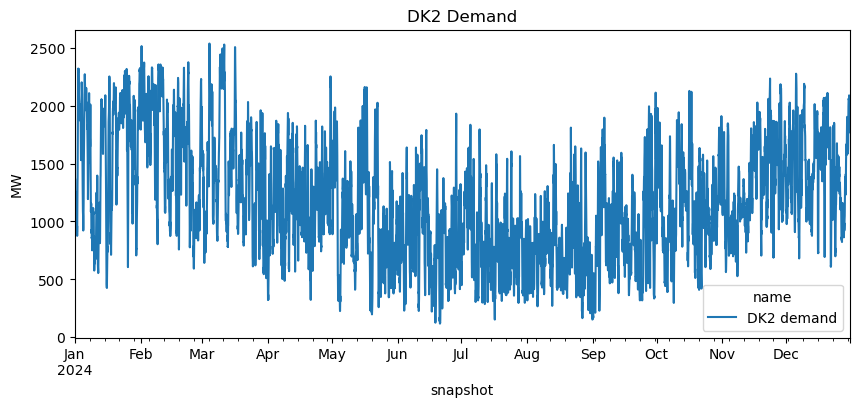

In [8]:
# Build Network for DK2
n = pypsa.Network()
n.set_snapshots(snapshots) 

n.add("Bus", "el_DK2")

n.add("Carrier",
      ["onshore", "offshore", "solar", "gas"],
      color=["dodgerblue", "aquamarine", "gold", "gray"],
      overwrite=True
      )

n.add("Load",
      "DK2 demand",
      bus="el_DK2",
      p_set=el_DK2.values, 
      overwrite=True
      )

# Final Verification and Plot
print(f"Network snapshots: {len(n.snapshots)}")
n.loads_t.p_set.plot(figsize=(10, 4), ylabel="MW", title="DK2 Demand")

In [9]:
n.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
el_DK2,1.0,,0.0,0.0,AC,,,1.0,0.0,inf,PQ,,


In [10]:

n.loads

,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
DK2 demand,el_DK2,,,0.0,0.0,-1.0,True


<Axes: title={'center': 'Week in December 2024'}, xlabel='snapshot', ylabel='Capacity Factor'>

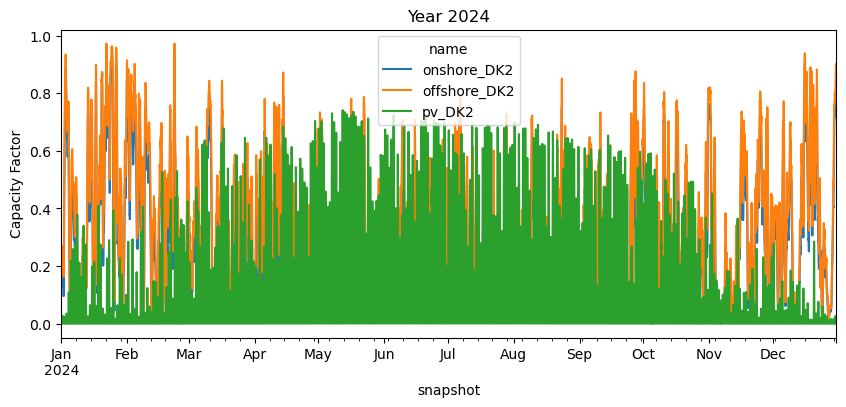

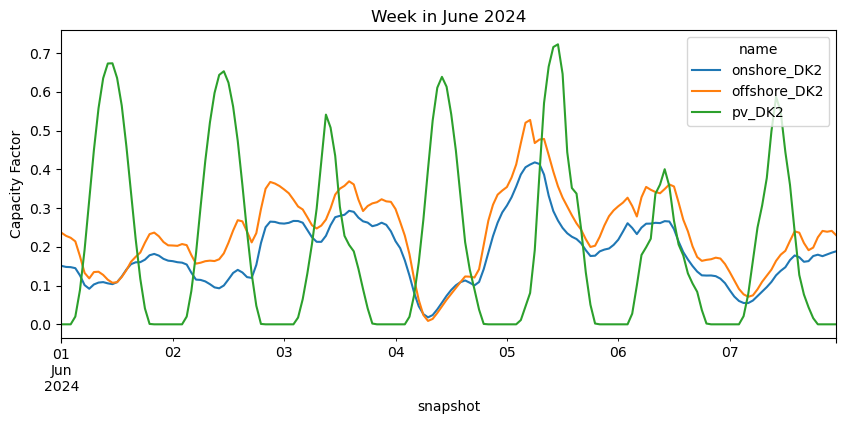

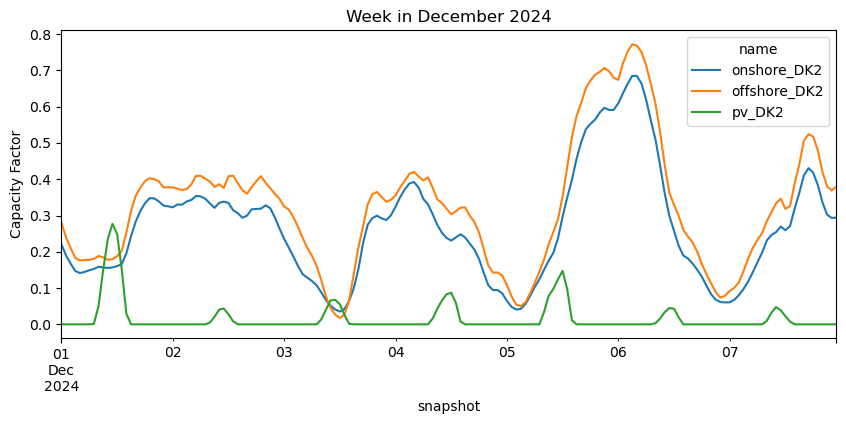

In [11]:
# Add Generators for DK2 
n.add("Generator", "onshore_DK2",
      bus="el_DK2",
      carrier="onshore",
      p_max_pu=onshore_DK.values,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      p_nom_extendable=True,
      p_nom_max=2500,
      overwrite=True
      )

n.add("Generator", "offshore_DK2",
      bus="el_DK2",
      carrier="offshore",
      p_max_pu=offshore_DK.values,
      capital_cost=costs.at["offwind", "capital_cost"],
      marginal_cost=costs.at["offwind", "marginal_cost"],
      p_nom_extendable=True,
      overwrite=True
      )

n.add("Generator", "pv_DK2",
      bus="el_DK2",
      carrier="solar",
      p_max_pu=pv_DK.values,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      p_nom_extendable=True,
      overwrite=True
      )

n.add("Generator", "CCGT_DK2",
      bus="el_DK2",
      carrier="gas",
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"],
      efficiency=costs.at["CCGT", "efficiency"],
      p_nom_extendable=True,
      overwrite=True
      )

# Plots
n.generators_t.p_max_pu.plot(figsize=(10, 4), ylabel="Capacity Factor", title="Year 2024")
n.generators_t.p_max_pu.loc["2024-06-01":"2024-06-07"].plot(figsize=(10, 4), ylabel="Capacity Factor", title="Week in June 2024")
n.generators_t.p_max_pu.loc["2024-12-01":"2024-12-07"].plot(figsize=(10, 4), ylabel="Capacity Factor", title="Week in December 2024")

In [12]:
import gurobipy as gp
try:
    # Attempt to create a large model dummy to test the license
    m = gp.Model("Test")
    print("Gurobi License successfully activated!")
    print(f"License expires on: {m.getParamInfo('Expiration')[2]}")
except Exception as e:
    print(f"Error: {e}")

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


Academic license - for non-commercial use only - expires 2027-04-21


INFO:gurobipy:Academic license - for non-commercial use only - expires 2027-04-21


Gurobi License successfully activated!
No parameters matching 'Expiration' found


INFO:gurobipy:No parameters matching 'Expiration' found


Error: 'NoneType' object is not subscriptable


In [13]:
#n.sanitize() Cannot be used because the Pypsa model installed here is a newer version. Instead the command is:
n.consistency_check()
n.optimize(solver_name="gurobi")
n.generators.p_nom_opt.div(1e3)  # MW -> GW



Index(['el_DK2'], dtype='object', name='name')
Index(['el_DK2'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 201.79it/s]
INFO:linopy.io: Writing time: 0.2s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

Solved in 143 iterations and 1.53 seconds (0.59 work units)


INFO:gurobipy:Solved in 143 iterations and 1.53 seconds (0.59 work units)


Optimal objective  9.318194991e+08


INFO:gurobipy:Optimal objective  9.318194991e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78845 duals
Objective: 9.32e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


name
onshore_DK2     2.500000
offshore_DK2    0.118521
pv_DK2          0.277929
CCGT_DK2        1.418175
Name: p_nom_opt, dtype: float64

In [14]:
n.buses_t.marginal_price

name,el_DK2
snapshot,
2024-01-01 00:00:00,81.007684
2024-01-01 01:00:00,81.007684
2024-01-01 02:00:00,81.007684
2024-01-01 03:00:00,81.007684
2024-01-01 04:00:00,81.007684
...,...
2024-12-30 19:00:00,1.903500
2024-12-30 20:00:00,1.903500
2024-12-30 21:00:00,1.903500


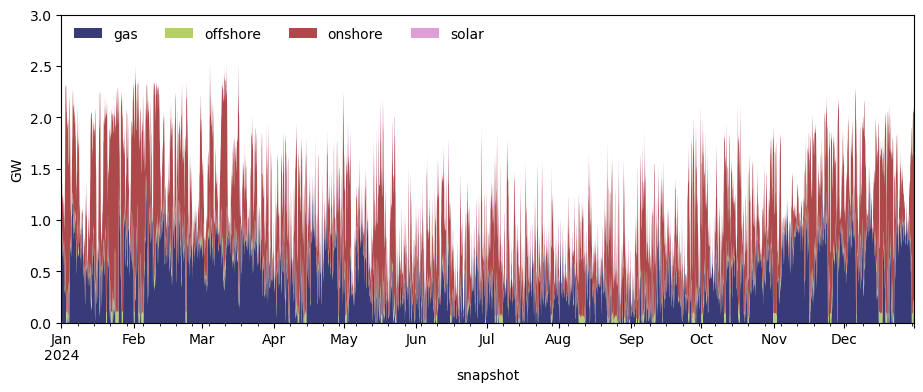

In [15]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T.div(1e3)
fig, ax = plt.subplots(figsize=(11, 4))

p_by_carrier.plot(
    kind="area",
    ax=ax,
    linewidth=0,
    cmap="tab20b",
)

ax.legend(ncol=5, loc="upper left", frameon=False)

ax.set_ylabel("GW")

ax.set_ylim(0, 3);

<Axes: xlabel='snapshot', ylabel='dispatch'>

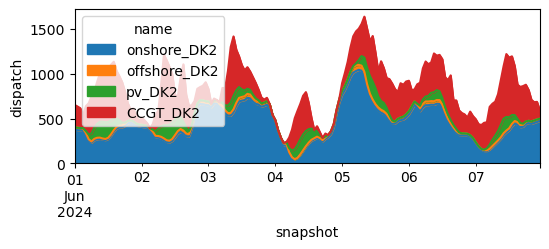

In [16]:
#Plot the dispatch time series for a week in summer
n.generators_t.p.loc["2024-06-01":"2024-06-07"].plot.area(figsize=(6, 2), ylabel="dispatch")

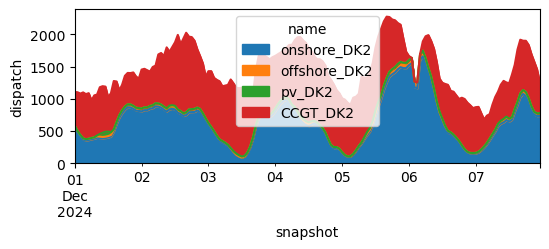

In [17]:
#Plot the dispatch time series for a week in winter
n.generators_t.p.loc["2024-12-01":"2024-12-07"].plot(kind="area",figsize=(6, 2), ylabel="dispatch")
ax.legend(ncol=3, frameon=False)

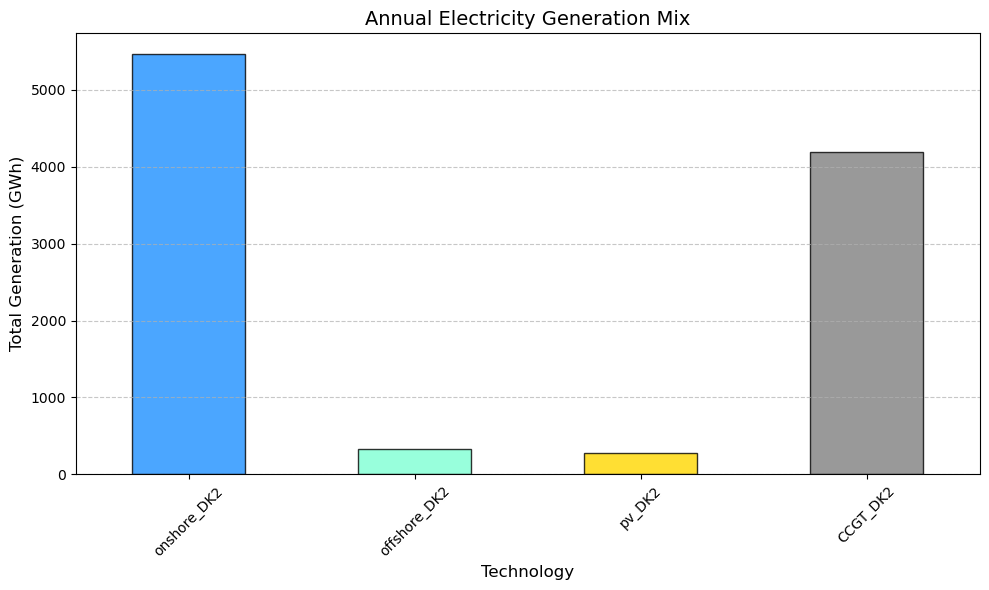

In [18]:
#Plot the annual electricity mix
annual_generation = n.generators_t.p.sum() / 1e3 #GWh
colors = [n.carriers.at[c, "color"] for c in n.generators.carrier]
ax = annual_generation.plot.bar(
    figsize=(10, 6), 
    color=colors, 
    edgecolor='black',
    alpha=0.8
)

ax.set_title("Annual Electricity Generation Mix", fontsize=14)
ax.set_ylabel("Total Generation (GWh)", fontsize=12)
ax.set_xlabel("Technology", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Calculated Capacity Factors:
name
onshore_DK2     0.249
offshore_DK2    0.322
pv_DK2          0.116
CCGT_DK2        0.338
dtype: float64


<Axes: title={'center': 'Technology Capacity Factors'}, xlabel='name', ylabel='Capacity Factor'>

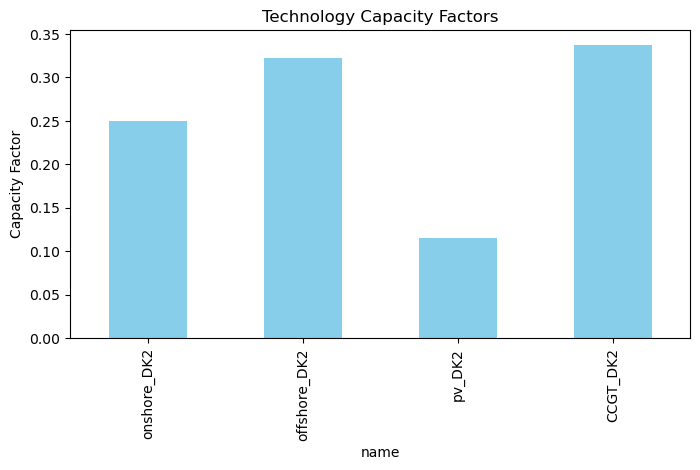

In [19]:
#Use the duration curves or the capacity factor to investigate the contribution of different technologies.
# Formula: Total Generation / (Optimized Capacity * Total Hours)
# We use p_nom_opt (the capacity the model decided to build)

CF = n.generators_t.p.sum() / (n.generators.p_nom_opt * len(n.snapshots))

print("Calculated Capacity Factors:")
print(CF.round(3))

# Optional: Plot as a bar chart
CF.plot.bar(figsize=(8, 4), ylabel="Capacity Factor", title="Technology Capacity Factors", color='skyblue')

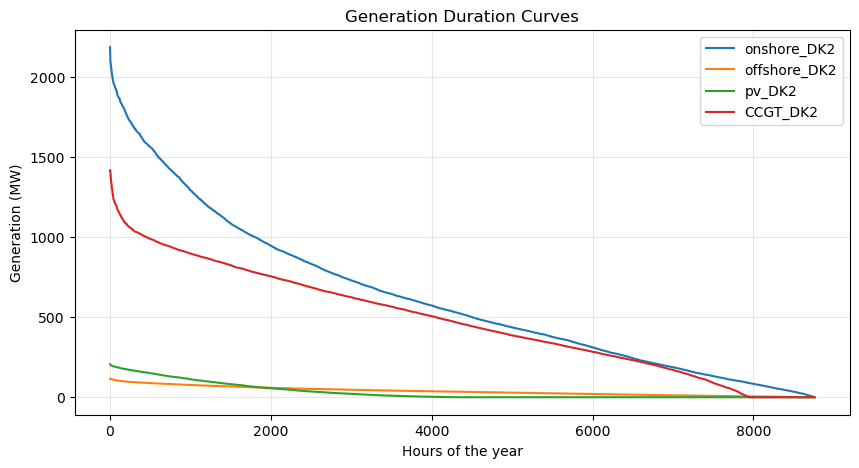

In [20]:
# Create a duration curve plot
fig, ax = plt.subplots(figsize=(10, 5))

for carrier in n.generators.index:
    # Get generation values, sort them descending, and reset the index to 0-8760
    duration_data = n.generators_t.p[carrier].sort_values(ascending=False).values
    ax.plot(duration_data, label=carrier)

ax.set_xlabel("Hours of the year")
ax.set_ylabel("Generation (MW)")
ax.set_title("Generation Duration Curves")
ax.legend()
ax.grid(alpha=0.3)

In [21]:
n.export_to_netcdf("results_task_A.nc")
print("Task A state saved to results_task_A.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'results_task_A.nc contains: loads, generators, buses, sub_networks, carriers


Task A state saved to results_task_A.nc


**PART B — Interannual Weather Variability**

Task B investigates how sensitive the optimal capacity mix is to interannual variability in solar and wind generation.

**Approach:**
- Offshore wind and solar capacity factors are taken from Renewables.ninja (1980–2024) for DK02 (Eastern Denmark = DK2).
- **Missing file:** `ninja-wind-country-DK-current_onshore-merra2.csv` was not uploaded. As a documented approximation, the offshore DK02 capacity factor profile is reused as an onshore wind proxy (correlation r=0.74 in 2024 vs. actual onshore from ConsumptionCoverage). For a complete analysis, upload the onshore ninja file and replace `on_y = off_y.copy()` with the actual profile.
- Electricity demand is fixed to the 2024 DK2 profile for all years so that only weather varies (standard academic approach).
- Non-leap years with full 8760 h in Ninja: **2015, 2017, 2018, 2019, 2021, 2022, 2023**.

In [22]:
# ============================================================
# TASK B — Multi-year weather sensitivity
# ============================================================
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Costs (reload for standalone execution) ---
costs = pd.read_csv("costs_2025.csv", index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")
defaults = {"FOM": 0, "VOM": 0, "efficiency": 1, "fuel": 0,
            "investment": 0, "lifetime": 25, "CO2 intensity": 0, "discount rate": 0.07}
costs = costs.value.unstack().fillna(defaults)
costs.at["CCGT", "fuel"]          = costs.at["gas", "fuel"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
ann = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (ann + costs["FOM"] / 100) * costs["investment"]

# --- Fixed demand: 2024 DK2 profile (8760 h) ---
snapshots_2024 = pd.date_range(start="2024-01-01 00:00", periods=8760, freq="h")

data_el_DK2 = pd.read_csv("ConsumptionCoverageNationalDecl.csv", sep=";", decimal=",")
data_el_DK2.columns = [c.strip().strip(",") for c in data_el_DK2.columns]
data_el_DK2.index = pd.to_datetime(data_el_DK2["HourUTC"], utc=True).dt.tz_localize(None)
el_DK2_fixed = data_el_DK2["ShareMWh"].reindex(snapshots_2024).ffill()

# --- Load all Ninja data once ---
def load_ninja(filename, skiprows=3):
    df = pd.read_csv(filename, skiprows=skiprows)
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df.set_index("time", inplace=True)
    return df

offshore_all = load_ninja("ninja-wind-country-DK-current_offshore-merra2.csv")
onshore_all = load_ninja("ninja-wind-country-DK-current_onshore-merra2.csv")
pv_all       = load_ninja("ninja-pv-country-DK-nuts2-merra2.csv")

# Non-leap years with full 8760h available in Ninja dataset
WEATHER_YEARS = [2015, 2017, 2018, 2019, 2021, 2022, 2023]

print(f"Running Task B for {len(WEATHER_YEARS)} weather years: {WEATHER_YEARS}")
print(f"Demand fixed to 2024 DK2 profile ({len(el_DK2_fixed)} hours)")
print("Note: Onshore wind uses offshore DK02 as proxy (onshore ninja file not uploaded)")


Running Task B for 7 weather years: [2015, 2017, 2018, 2019, 2021, 2022, 2023]
Demand fixed to 2024 DK2 profile (8760 hours)
Note: Onshore wind uses offshore DK02 as proxy (onshore ninja file not uploaded)


In [23]:
# ============================================================
# TASK B — Optimisation loop across weather years
# ============================================================
results_b = {}   # year -> dict of results

for year in WEATHER_YEARS:
    print(f"\n--- Optimising year {year} ---")
    snapshots_y = pd.date_range(start=f"{year}-01-01 00:00", periods=8760, freq="h")

    # Extract weather profiles for this year (DK02 = Eastern Denmark)
    off_y = ((offshore_all["DK01"] + offshore_all["DK02"]) / 2).reindex(snapshots_y).ffill()
    on_y  = ((onshore_all["DK01"]  + onshore_all["DK02"])  / 2).reindex(snapshots_y).ffill()
    pv_y  = ((pv_all["DK01"]       + pv_all["DK02"])       / 2).reindex(snapshots_y).ffill()
  
    # Build network — demand values are fixed from 2024; only weather CFs vary
    n_b = pypsa.Network()
    n_b.set_snapshots(snapshots_y)
    n_b.add("Bus", "el_DK2")
    n_b.add("Carrier", ["onshore", "offshore", "solar", "gas"])
    n_b.add("Load", "DK2 demand", bus="el_DK2", p_set=el_DK2_fixed.values)

    n_b.add("Generator", "onshore_DK2",
            bus="el_DK2", carrier="onshore",
            p_max_pu=on_y.values,
            capital_cost=costs.at["onwind",  "capital_cost"],
            marginal_cost=costs.at["onwind",  "marginal_cost"],
            p_nom_extendable=True, p_nom_max=2500)

    n_b.add("Generator", "offshore_DK2",
            bus="el_DK2", carrier="offshore",
            p_max_pu=off_y.values,
            capital_cost=costs.at["offwind", "capital_cost"],
            marginal_cost=costs.at["offwind", "marginal_cost"],
            p_nom_extendable=True)

    n_b.add("Generator", "pv_DK2",
            bus="el_DK2", carrier="solar",
            p_max_pu=pv_y.values,
            capital_cost=costs.at["solar",   "capital_cost"],
            marginal_cost=costs.at["solar",   "marginal_cost"],
            p_nom_extendable=True)

    n_b.add("Generator", "CCGT_DK2",
            bus="el_DK2", carrier="gas",
            capital_cost=costs.at["CCGT",    "capital_cost"],
            marginal_cost=costs.at["CCGT",   "marginal_cost"],
            efficiency=costs.at["CCGT",      "efficiency"],
            p_nom_extendable=True)

    n_b.optimize(solver_name="gurobi")

    # Realised capacity factors
    cf = (n_b.generators_t.p.sum() / (n_b.generators.p_nom_opt * 8760)).round(3)

    results_b[year] = {
        "p_nom_opt_GW": n_b.generators.p_nom_opt.div(1e3).round(3),
        "cost_BEUR":    round(n_b.objective / 1e9, 4),
        "cf":           cf,
    }
    print(f"  Objective: {n_b.objective/1e9:.4f} B EUR/yr")
    print(f"  Capacities (GW):\n{results_b[year]['p_nom_opt_GW'].to_string()}")

print("\nTask B optimisation complete.")



--- Optimising year 2015 ---


Index(['el_DK2'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 180.11it/s]
INFO:linopy.io: Writing time: 0.16s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


...

Solved in 8929 iterations and 1.59 seconds (0.66 work units)


INFO:gurobipy:Solved in 8929 iterations and 1.59 seconds (0.66 work units)


Optimal objective  1.076908363e+09


INFO:gurobipy:Optimal objective  1.076908363e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78845 duals
Objective: 1.08e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


  Objective: 1.0769 B EUR/yr
  Capacities (GW):
name
onshore_DK2     1.923
offshore_DK2    0.000
pv_DK2          0.372
CCGT_DK2        2.265

Task B optimisation complete.


=== Optimal Capacities (GW) across weather years ===
name  onshore_DK2  offshore_DK2  pv_DK2  CCGT_DK2
2015        2.043           0.0   0.287     2.306
2017        1.947           0.0   0.639     2.287
2018        1.591           0.0   1.054     2.381
2019        1.816           0.0   0.731     2.201
2021        1.588           0.0   0.351     2.345
2022        2.064           0.0   0.469     2.178
2023        1.923           0.0   0.372     2.265

=== Mean & Std Dev of Installed Capacity (GW) ===
              Mean GW  Std GW
name                         
onshore_DK2     1.853   0.198
offshore_DK2    0.000   0.000
pv_DK2          0.558   0.271
CCGT_DK2        2.280   0.073


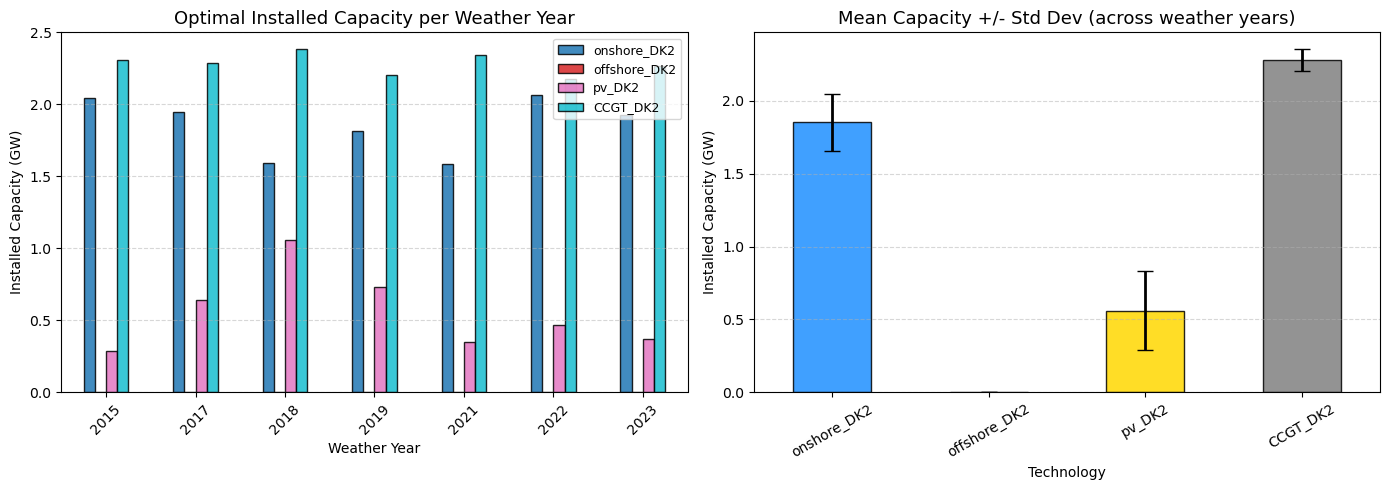

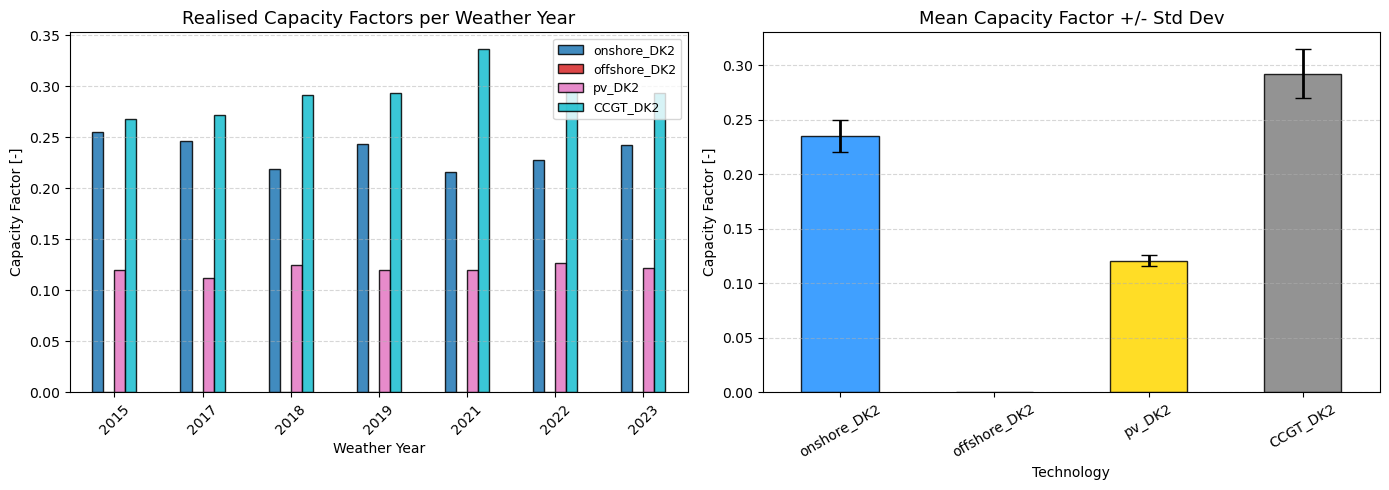

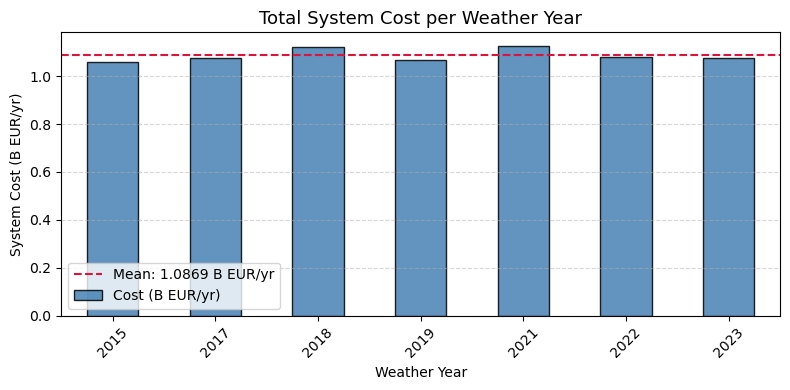

System cost: mean = 1.0869 B EUR/yr,  std = 0.0259 B EUR/yr


In [24]:
# ============================================================
# TASK B — Plots: Average capacity & variability per technology
# ============================================================

# Assemble DataFrames
cap_df = pd.DataFrame(
    {yr: res["p_nom_opt_GW"] for yr, res in results_b.items()}
).T   # rows = years, cols = generators

cf_df = pd.DataFrame(
    {yr: res["cf"] for yr, res in results_b.items()}
).T

cost_s = pd.Series(
    {yr: res["cost_BEUR"] for yr, res in results_b.items()},
    name="Cost (B EUR/yr)"
)

print("=== Optimal Capacities (GW) across weather years ===")
print(cap_df.round(3))
print()
print("=== Mean & Std Dev of Installed Capacity (GW) ===")
print(pd.DataFrame({"Mean GW": cap_df.mean(), "Std GW": cap_df.std()}).round(3))

COLORS = ["dodgerblue", "aquamarine", "gold", "grey"]

# ---- Figure 1: Capacities per year + mean+std ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap_df.plot(kind="bar", ax=axes[0], colormap="tab10", edgecolor="black", alpha=0.85)
axes[0].set_title("Optimal Installed Capacity per Weather Year", fontsize=13)
axes[0].set_xlabel("Weather Year")
axes[0].set_ylabel("Installed Capacity (GW)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

mean_cap = cap_df.mean()
std_cap  = cap_df.std()
mean_cap.plot(
    kind="bar", yerr=std_cap, ax=axes[1],
    color=COLORS[:len(mean_cap)], edgecolor="black",
    capsize=6, alpha=0.85, error_kw={"elinewidth": 2, "ecolor": "black"}
)
axes[1].set_title("Mean Capacity +/- Std Dev (across weather years)", fontsize=13)
axes[1].set_xlabel("Technology")
axes[1].set_ylabel("Installed Capacity (GW)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Figure 2: Capacity factor variability ----
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

cf_df.plot(kind="bar", ax=axes2[0], colormap="tab10", edgecolor="black", alpha=0.85)
axes2[0].set_title("Realised Capacity Factors per Weather Year", fontsize=13)
axes2[0].set_xlabel("Weather Year")
axes2[0].set_ylabel("Capacity Factor [-]")
axes2[0].legend(loc="upper right", fontsize=9)
axes2[0].tick_params(axis="x", rotation=45)
axes2[0].grid(axis="y", linestyle="--", alpha=0.5)

mean_cf = cf_df.mean()
std_cf  = cf_df.std()
mean_cf.plot(
    kind="bar", yerr=std_cf, ax=axes2[1],
    color=COLORS[:len(mean_cf)], edgecolor="black",
    capsize=6, alpha=0.85, error_kw={"elinewidth": 2, "ecolor": "black"}
)
axes2[1].set_title("Mean Capacity Factor +/- Std Dev", fontsize=13)
axes2[1].set_xlabel("Technology")
axes2[1].set_ylabel("Capacity Factor [-]")
axes2[1].tick_params(axis="x", rotation=30)
axes2[1].grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Figure 3: System cost variability ----
fig3, ax3 = plt.subplots(figsize=(8, 4))
cost_s.plot(kind="bar", ax=ax3, color="steelblue", edgecolor="black", alpha=0.85)
ax3.axhline(
    cost_s.mean(), color="crimson", linestyle="--",
    label=f"Mean: {cost_s.mean():.4f} B EUR/yr"
)
ax3.set_title("Total System Cost per Weather Year", fontsize=13)
ax3.set_xlabel("Weather Year")
ax3.set_ylabel("System Cost (B EUR/yr)")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", linestyle="--", alpha=0.5)
ax3.legend()
plt.tight_layout()
plt.show()

print(f"System cost: mean = {cost_s.mean():.4f} B EUR/yr,  std = {cost_s.std():.4f} B EUR/yr")

**PART C**

StorageUnit covers the "Peak Demand".

Store covers the seasonal demand.

In [25]:

# ===============================
# BATTERY STORAGE (DK2)
# ===============================
n.add("StorageUnit", "battery_DK2",
      bus="el_DK2",
      carrier="battery",
      
      p_nom_extendable=True,
      
      capital_cost=costs.at["battery storage", "capital_cost"],
      marginal_cost=costs.at["battery storage", "marginal_cost"],
      
      efficiency_store=0.9,
      efficiency_dispatch=0.9,
      max_hours=6,
      
      cyclic_state_of_charge=True,
      overwrite=True
)



print("All storage technologies added to DK2 successfully.")

All storage technologies added to DK2 successfully.


In [26]:
n.optimize(solver_name="gurobi")

Index(['el_DK2'], dtype='object', name='name')
Index(['battery_DK2'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 231.00it/s]
INFO:linopy.io: Writing time: 0.31s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

Solved in 16446 iterations and 2.83 seconds (1.42 work units)


INFO:gurobipy:Solved in 16446 iterations and 2.83 seconds (1.42 work units)


Optimal objective  8.817988662e+08


INFO:gurobipy:Optimal objective  8.817988662e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140166 duals
Objective: 8.82e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [27]:
n.objective / 1e9  # Convert from EUR to Billion EUR

0.8817988661682219

In [28]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW
#optimal capacities in system with battery

name
onshore_DK2     2.500000
offshore_DK2    0.000000
pv_DK2          0.787842
CCGT_DK2        0.954576
Name: p_nom_opt, dtype: float64

### Comparison with previous system without storage
onshore_DK2     2.902232

offshore_DK2    0.000000

pv_DK2          0.272619

CCGT_DK2        1.406409

In [29]:
#The optimised battery capacity can be retrieved as 
n.storage_units.p_nom_opt.div(1e3)  # MW -> GW

name
battery_DK2    1.08807
Name: p_nom_opt, dtype: float64

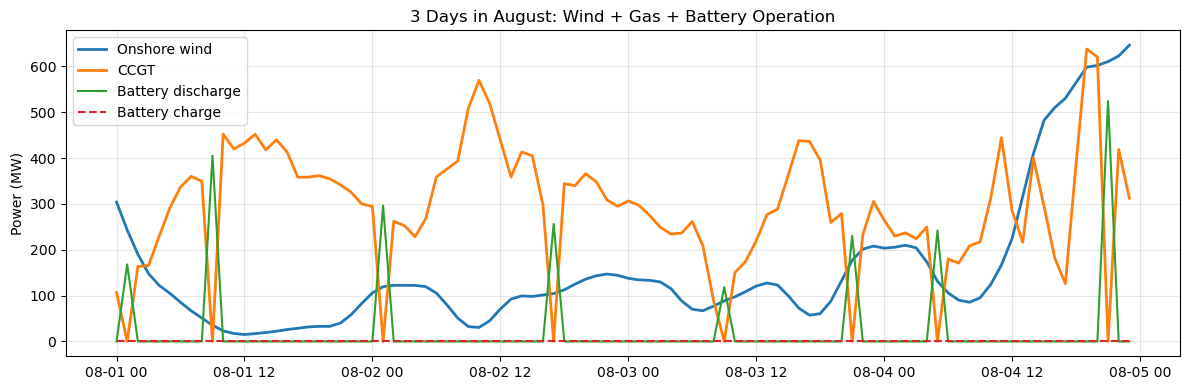

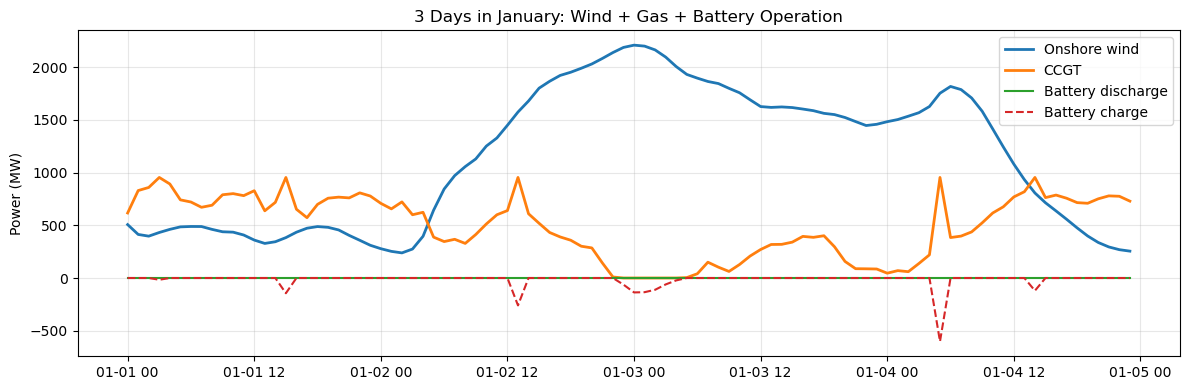

In [30]:
import matplotlib.pyplot as plt

# =========================
# TIME WINDOWS (3 days each)
# =========================
summer_slice = slice("2024-08-01", "2024-08-04")
winter_slice = slice("2024-01-01", "2024-01-04")

# =========================
# DATA
# =========================
battery_p = n.storage_units_t.p["battery_DK2"]
onshore = n.generators_t.p["onshore_DK2"]
ccgt = n.generators_t.p["CCGT_DK2"]

# =========================
# PLOT FUNCTION
# =========================
def plot_period(time_slice, title):

    batt = battery_p.loc[time_slice]
    wind = onshore.loc[time_slice]
    gas = ccgt.loc[time_slice]

    x = wind.index

    fig, ax = plt.subplots(figsize=(12, 4))

    # =========================
    # GENERATION
    # =========================
    ax.plot(x, wind.values, label="Onshore wind", linewidth=2)
    ax.plot(x, gas.values, label="CCGT", linewidth=2)

    # =========================
    # BATTERY (ONLY CHARGE / DISCHARGE)
    # =========================
    ax.plot(x, batt.clip(lower=0).values, label="Battery discharge")
    ax.plot(x, batt.clip(upper=0).values, linestyle="--", label="Battery charge")

    # =========================
    # STYLE
    # =========================
    ax.set_ylabel("Power (MW)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# =========================
# RUN PLOTS
# =========================
plot_period(summer_slice, "3 Days in August: Wind + Gas + Battery Operation")
plot_period(winter_slice, "3 Days in January: Wind + Gas + Battery Operation")

In [31]:
#soc.info() Cannot run in my version
n.statistics()
print(n)

n.storage_units_t.state_of_charge.info()


PyPSA Network 'Unnamed Network'
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2024-01-01 00:00:00 to 2024-12-30 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   battery_DK2  8760 non-null   float64
dtypes: float64(1)
memory usage: 394.9 KB


In [32]:
n.export_to_netcdf("results_task_C.nc")
print("Task C state saved to results_task_C.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'results_task_C.nc contains: loads, storage_units, generators, buses, sub_networks, carriers


Task C state saved to results_task_C.nc


### Part D

In [33]:
# ============================================================
# ENTSO-E DEMAND LOADER (NO, SE, FI)
# ============================================================
def load_entsoe_demand(filename, snapshots, resample_hourly=False):
    df = pd.read_csv(filename)
    
    
    df['time'] = (df.iloc[:, 0]
                  .str.split(' - ').str[0]
                  .str.replace(r'\s*\(CE[S]?T\)', '', regex=True)
                  .str.strip())
    
    
    df['time'] = pd.to_datetime(df['time'], format='%d/%m/%Y %H:%M')
    df['time'] = df['time'].dt.tz_localize('Europe/Paris',
                                            ambiguous='infer',
                                            nonexistent='shift_forward')
    df['time'] = df['time'].dt.tz_convert('UTC').dt.tz_localize(None)
    df.set_index('time', inplace=True)
    
    
    load_col = [c for c in df.columns if 'Actual Total Load' in c][0]
    col = df[load_col]
    
    if col.dtype == object:

        series = pd.to_numeric(col.str.replace(',', '.'), errors='coerce')
    else:

        series = pd.to_numeric(col, errors='coerce')
    
    if resample_hourly:
        series = series.resample('h').mean()
    
    return series.reindex(snapshots).ffill()
el_SE = load_entsoe_demand(
    "GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300.csv", snapshots)
el_NO = load_entsoe_demand(
    "GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300 (1).csv", snapshots)
el_FI = load_entsoe_demand(
    "GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300 (2).csv", snapshots, 
    resample_hourly=True)
# ============================================================
# RENEWABLES.NINJA LOADER (NO, SE, FI )
# ============================================================
def load_ninja_national(filename, snapshots):
    df = pd.read_csv(filename, skiprows=3)
    df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_localize(None)
    df.set_index('time', inplace=True)
    return df['NATIONAL'].reindex(snapshots).ffill()

# Norway
onshore_NO  = load_ninja_national("ninja-wind-country-NO-current_onshore-merra2.csv",  snapshots)
offshore_NO = load_ninja_national("ninja-wind-country-NO-current_offshore-merra2.csv", snapshots)
pv_NO       = load_ninja_national("ninja-pv-country-NO-national-merra2.csv",           snapshots)

# Sweden
onshore_SE  = load_ninja_national("ninja-wind-country-SE-current_onshore-merra2.csv",  snapshots)
offshore_SE = load_ninja_national("ninja-wind-country-SE-current_offshore-merra2.csv", snapshots)
pv_SE       = load_ninja_national("ninja-pv-country-SE-national-merra2.csv",           snapshots)

# Finland
onshore_FI  = load_ninja_national("ninja-wind-country-FI-current_onshore-merra2.csv",  snapshots)
offshore_FI = load_ninja_national("ninja-wind-country-FI-current_offshore-merra2.csv", snapshots)
pv_FI       = load_ninja_national("ninja-pv-country-FI-national-merra2.csv",           snapshots)


In [34]:
# ============================================================
# NETWORK SETUP
# ============================================================
n = pypsa.Network()
n.set_snapshots(snapshots)

# ============================================================
# CARRIERS
# ============================================================
n.add("Carrier", ["onshore", "offshore", "solar", "gas", "battery", "AC"],
      overwrite=True)

# ============================================================
# BUSES
# ============================================================
n.add("Bus", "electricity_DK2", carrier="AC")

for country in ["NO", "SE", "FI"]:
    n.add("Bus", f"electricity_{country}", carrier="AC")

for bus in n.buses.index:
    n.buses.at[bus, "v_nom"] = 400  # kV

# ============================================================
# LOADS
# ============================================================
n.add("Load", "DK2 demand", bus="electricity_DK2", p_set=el_DK2.values)
n.add("Load", "NO demand",  bus="electricity_NO",  p_set=el_NO.values)
n.add("Load", "SE demand",  bus="electricity_SE",  p_set=el_SE.values)
n.add("Load", "FI demand",  bus="electricity_FI",  p_set=el_FI.values)

# ============================================================
# GENERATORS — Denmark (single DK2 node, averaged CFs)
# ============================================================
n.add("Generator", "onshore_DK2",
      bus="electricity_DK2", carrier="onshore",
      p_nom_extendable=True,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      p_max_pu=onshore_DK.values)

n.add("Generator", "offshore_DK2",
      bus="electricity_DK2", carrier="offshore",
      p_nom_extendable=True,
      capital_cost=costs.at["offwind", "capital_cost"],
      marginal_cost=costs.at["offwind", "marginal_cost"],
      p_max_pu=offshore_DK.values)

n.add("Generator", "solar_DK2",
      bus="electricity_DK2", carrier="solar",
      p_nom_extendable=True,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      p_max_pu=pv_DK.values)

n.add("Generator", "CCGT_DK2",
      bus="electricity_DK2", carrier="gas",
      p_nom_extendable=True,
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"])

# ============================================================
# GENERATORS — Neighbouring countries
# ============================================================
for country, cf_on, cf_off, cf_pv in [
    ("NO", onshore_NO, offshore_NO, pv_NO),
    ("SE", onshore_SE, offshore_SE, pv_SE),
    ("FI", onshore_FI, offshore_FI, pv_FI),
]:
    n.add("Generator", f"onshore_{country}",
          bus=f"electricity_{country}", carrier="onshore",
          p_nom_extendable=True,
          capital_cost=costs.at["onwind", "capital_cost"],
          marginal_cost=costs.at["onwind", "marginal_cost"],
          p_max_pu=cf_on.values)

    n.add("Generator", f"offshore_{country}",
          bus=f"electricity_{country}", carrier="offshore",
          p_nom_extendable=True,
          capital_cost=costs.at["offwind", "capital_cost"],
          marginal_cost=costs.at["offwind", "marginal_cost"],
          p_max_pu=cf_off.values)

    n.add("Generator", f"solar_{country}",
          bus=f"electricity_{country}", carrier="solar",
          p_nom_extendable=True,
          capital_cost=costs.at["solar", "capital_cost"],
          marginal_cost=costs.at["solar", "marginal_cost"],
          p_max_pu=cf_pv.values)

    n.add("Generator", f"CCGT_{country}",
          bus=f"electricity_{country}", carrier="gas",
          p_nom_extendable=True,
          capital_cost=costs.at["CCGT", "capital_cost"],
          marginal_cost=costs.at["CCGT", "marginal_cost"])

# ============================================================
# INTERCONNECTIONS
# ============================================================
lines = {
    "DK2-NO": ("electricity_DK2", "electricity_NO", 1700), #Skagerrak link
    "DK2-SE": ("electricity_DK2", "electricity_SE",  740), #Oresund link
    "NO-SE":  ("electricity_NO",  "electricity_SE", 3500),
    "SE-FI":  ("electricity_SE",  "electricity_FI", 1200),
}

for name, (bus0, bus1, s_nom) in lines.items():
    n.add("Line", name,
          bus0=bus0, bus1=bus1,
          carrier="AC",
          s_nom=s_nom,
          s_nom_extendable=False,
          x=0.1)

# ============================================================
# STORAGE — Battery only
# ============================================================
for bus in ["DK2", "NO", "SE", "FI"]:
    n.add("StorageUnit", f"battery_{bus}",
          bus=f"electricity_{bus}",
          carrier="battery",
          p_nom_extendable=True,
          capital_cost=costs.at["battery storage", "capital_cost"],
          marginal_cost=costs.at["battery storage", "marginal_cost"],
          efficiency_store=0.9,
          efficiency_dispatch=0.9,
          max_hours=6)

# ============================================================
# VERIFY
# ============================================================
print(f"Buses:         {len(n.buses)}")
print(f"Loads:         {len(n.loads)}")
print(f"Generators:    {len(n.generators)}")
print(f"Lines:         {len(n.lines)}")
print(f"Storage Units: {len(n.storage_units)}")
print(f"Snapshots:     {len(n.snapshots)}")

print("\nLines summary:")
print(n.lines[["bus0", "bus1", "s_nom", "x"]])

print("\nStorage Units summary:")
print(n.storage_units[["bus", "carrier", "p_nom_extendable", "max_hours"]])

Buses:         4
Loads:         4
Generators:    16
Lines:         4
Storage Units: 4
Snapshots:     8760

Lines summary:
                   bus0            bus1   s_nom    x
name                                                
DK2-NO  electricity_DK2  electricity_NO  1700.0  0.1
DK2-SE  electricity_DK2  electricity_SE   740.0  0.1
NO-SE    electricity_NO  electricity_SE  3500.0  0.1
SE-FI    electricity_SE  electricity_FI  1200.0  0.1

Storage Units summary:
                         bus  carrier  p_nom_extendable  max_hours
name                                                              
battery_DK2  electricity_DK2  battery              True        6.0
battery_NO    electricity_NO  battery              True        6.0
battery_SE    electricity_SE  battery              True        6.0
battery_FI    electricity_FI  battery              True        6.0


In [35]:
n.optimize(solver_name="gurobi")

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 126.62it/s]
INFO:linopy.io: Writing time: 0.96s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

Solved in 91140 iterations and 32.33 seconds (13.00 work units)


INFO:gurobipy:Solved in 91140 iterations and 32.33 seconds (13.00 work units)


Optimal objective  2.570874578e+10


INFO:gurobipy:Optimal objective  2.570874578e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 280340 primals, 639500 duals
Objective: 2.57e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [36]:
print(n.generators[["p_nom_opt"]])
print(n.lines[["s_nom_opt"]])
print(n.links[["p_nom_opt"]])
print( n.lines_t.p0)
print(n.storage_units[["p_nom_opt"]])

                 p_nom_opt
name                      
onshore_DK2    2104.825667
offshore_DK2      0.000000
solar_DK2         0.000000
CCGT_DK2       1649.605949
onshore_NO        0.000000
offshore_NO   27487.091666
solar_NO          0.000000
CCGT_NO        9634.534931
onshore_SE    38273.640180
offshore_SE       0.000000
solar_SE          0.000000
CCGT_SE       11284.593980
onshore_FI    25291.103479
offshore_FI       0.000000
solar_FI          0.000000
CCGT_FI        7470.634577
        s_nom_opt
name             
DK2-NO     1700.0
DK2-SE      740.0
NO-SE      3500.0
SE-FI      1200.0
Empty DataFrame
Columns: [p_nom_opt]
Index: []
name                      DK2-NO      DK2-SE        NO-SE   SE-FI
snapshot                                                         
2024-01-01 00:00:00 -1700.000000  740.000000  2440.000000  1200.0
2024-01-01 01:00:00 -1635.405035  740.000000  2375.405035  1200.0
2024-01-01 02:00:00   -12.692347  740.000000   752.692347  1200.0
2024-01-01 03:00:00 -1700.000

In [37]:
n.generators_t.p
total_energy_MWh = n.generators_t.p.sum().sum()
total_energy_TWh = total_energy_MWh / 1e6

print(total_energy_TWh)

364.8408304790039


In [38]:
import pandas as pd

# flussi
flows = n.lines_t.p0

# capacità linee
cap = n.lines.s_nom_opt

# utilizzo medio assoluto (MW)
avg_flow = flows.abs().mean()

# utilizzo relativo (%)
utilization = avg_flow / cap * 100

print(utilization)

name
DK2-NO    70.789292
DK2-SE    91.733870
NO-SE     49.459618
SE-FI     94.584461
dtype: float64


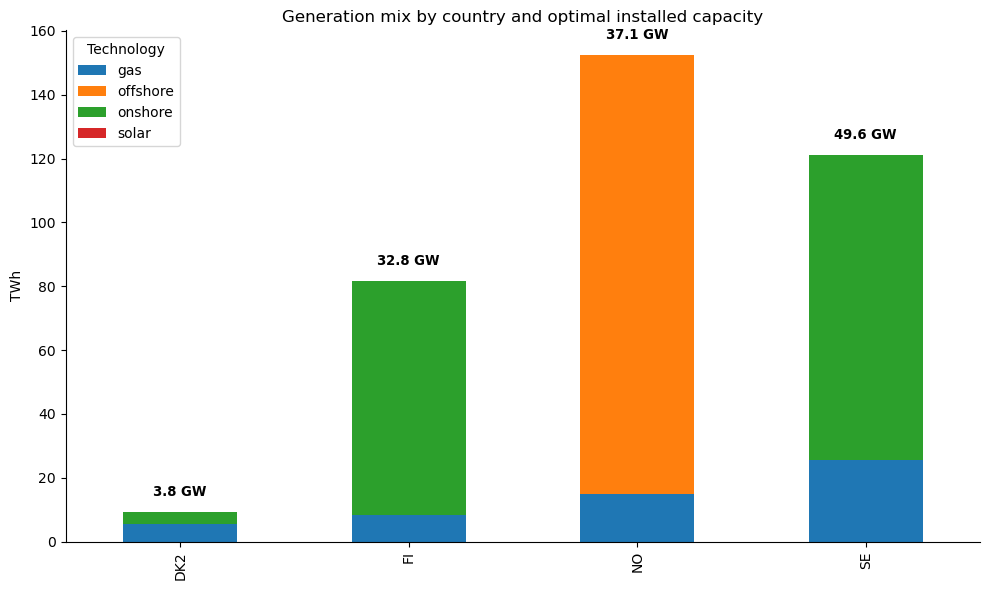

In [39]:
# --- GENERATION ---
gen = n.generators_t.p
gen_bus = n.generators.bus
gen_tech = n.generators.carrier

gen.columns = pd.MultiIndex.from_arrays([gen_bus, gen_tech])

# FIX groupby
gen_multi = gen.T.groupby(level=[0,1]).sum().T

gen_multi_annual = gen_multi.sum() / 1e6
gen_plot = gen_multi_annual.unstack().fillna(0)

# pulizia nomi
gen_plot.index = [i.replace("electricity_", "") for i in gen_plot.index]

# --- CAPACITÀ ---
cap = n.generators.p_nom_opt
cap.index = pd.MultiIndex.from_arrays([n.generators.bus, n.generators.carrier])

cap_by_bus = cap.groupby(level=0).sum() / 1000  # GW

# FIX nomi anche qui
cap_by_bus.index = [i.replace("electricity_", "") for i in cap_by_bus.index]

# --- PLOT ---
fig, ax = plt.subplots(figsize=(10,6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

gen_plot.plot(kind="bar", stacked=True, ax=ax)

# etichette capacità
for i, country in enumerate(gen_plot.index):
    total_gen = gen_plot.loc[country].sum()
    total_cap = cap_by_bus.loc[country]
    
    ax.text(i, total_gen + 5, f"{total_cap:.1f} GW",
            ha='center', fontsize=9.5, fontweight='bold')
    

plt.ylabel("TWh")
plt.title("Generation mix by country and optimal installed capacity")
plt.legend(title="Technology")
plt.tight_layout()
plt.savefig("genmix_qD.png", dpi=300)
plt.show()

DK2-NO: zero crossing at hour ~3094
DK2-SE: zero crossing at hour ~6976
NO-SE: zero crossing at hour ~6741
SE-FI: zero crossing at hour ~4961


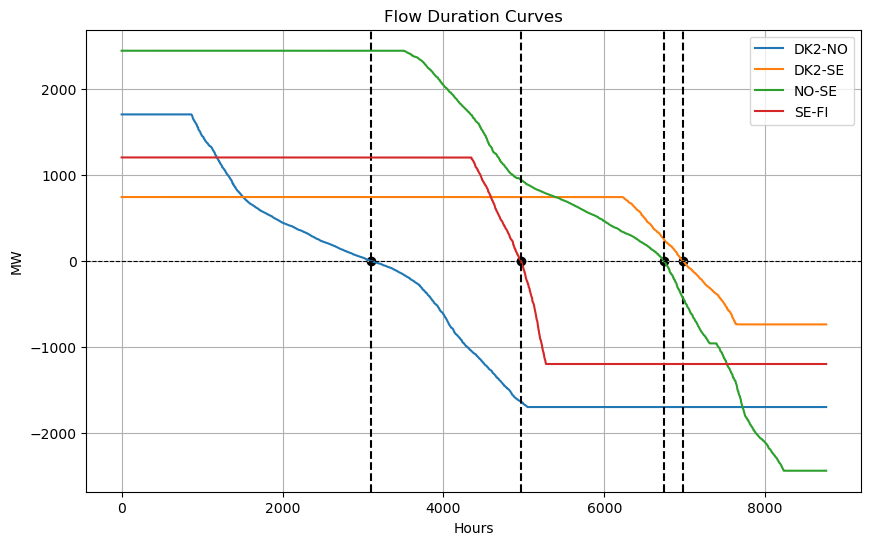

In [40]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for line in flows.columns:
    # ordino
    f = flows[line].sort_values(ascending=False).reset_index(drop=True)
    
    # plot curva
    plt.plot(f, label=line)
    
    # ---- zero crossing ----
    # trovo dove cambia segno
    sign_change = np.where(np.diff(np.sign(f)))[0]
    
    if len(sign_change) > 0:
        idx = sign_change[0]
        
        # punto crossing
        plt.scatter(idx, f.iloc[idx], color="black")
        
        # linea verticale
        plt.axvline(x=idx, linestyle='--', color= "black")
        
        # (opzionale) stampa info utile
        print(f"{line}: zero crossing at hour ~{idx}")

# linea orizzontale zero
plt.axhline(0, linestyle='--', color="black", linewidth=0.8)

plt.legend()
plt.title("Flow Duration Curves")
plt.ylabel("MW")
plt.xlabel("Hours")
plt.grid()
plt.savefig("flow_duration_curve.png", dpi=300, bbox_inches='tight')
plt.show()

### Part B - TaskF

In [41]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [42]:
print(n.generators.carrier.unique())

['onshore' 'offshore' 'solar' 'gas']


## How I proceed with Task f
At the end of Part A, the network is being reset -> Therefore I need to reenter the generators and carriers.

Step 1: Update the generator definitions; Go to the cells in Part A and add the carrier argument for every generator

In [43]:
# --- 0. LOAD: Start from Task C results ---
n = pypsa.Network("results_task_C.nc")


INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units, sub_networks


In [44]:
n.generators.head()

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
onshore_DK2,el_DK2,Slack,,0.0,0.0,True,0.0,2500.0,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2500.000000
offshore_DK2,el_DK2,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.000000
pv_DK2,el_DK2,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,787.841891
CCGT_DK2,el_DK2,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,954.576260


In [45]:
# --- 1. DYNAMIC DATA INCORPORATION ---
# Extract values from your technology-data 'costs' DataFrame
gas_intensity = costs.at["gas", "CO2 intensity"] # tCO2/MWh_th
gas_efficiency = costs.at["CCGT", "efficiency"]

# Update Carriers and Generators
n.add("Carrier", "gas", co2_emissions=gas_intensity, overwrite=True)
n.add("Carrier", "onshore", co2_emissions=0.0, overwrite=True)
n.add("Carrier", "offshore", co2_emissions=0.0, overwrite=True)
n.add("Carrier", "solar", co2_emissions=0.0, overwrite=True)

# Ensure CCGT generator has the correct efficiency for CO2 math
n.generators.at["CCGT_DK2", "efficiency"] = gas_efficiency

# --- 2. SENSITIVITY PARAMETERS ---
# 1990 Baseline for DK2 (approx 40% of Denmark's 25Mt energy emissions)
baseline_1990 = 10e6 
# Range of allowances from 100% down to 0% (Problem 9.3 methodology)
allowances = np.linspace(1.0, 0.0, 11) 

# Data storage
system_costs = []
co2_prices = []
gen_mix = []

# --- 3. THE SENSITIVITY LOOP ---
for limit in allowances:
    # Update CO2 Limit
    current_cap = baseline_1990 * limit
    
    if "CO2Limit" in n.global_constraints.index:
        n.remove("GlobalConstraint", "CO2Limit")
    
    n.add("GlobalConstraint", "CO2Limit",
          type="primary_energy",
          constant=current_cap,
          carrier_attribute="co2_emissions",
          sense="<=")

    # Solve
    n.optimize(solver_name='gurobi')

    # Store results (Task F & H)
    system_costs.append(n.objective) # Total System Cost
    co2_prices.append(n.global_constraints.at["CO2Limit", "mu"]) # Shadow Price
    
    # Store Generation Mix (Task F)
    gen = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().sum()
    gen_mix.append(gen)

# --- 4. DATA PROCESSING ---
results_df = pd.DataFrame({
    "System Cost (MEUR)": np.array(system_costs) / 1e6,
    "CO2 Price (EUR/t)": np.abs(co2_prices), # mu is often negative in linopy
    "Allowance (%)": allowances * 100
}).set_index("Allowance (%)")

df_gen = pd.DataFrame(gen_mix, index=allowances * 100)

Index(['el_DK2'], dtype='object', name='name')
Index(['battery_DK2'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 229.78it/s]
INFO:linopy.io: Writing time: 0.37s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

INFO:gurobipy:


Solved in 8376 iterations and 2.85 seconds (2.11 work units)


INFO:gurobipy:Solved in 8376 iterations and 2.85 seconds (2.11 work units)


Optimal objective  1.574319503e+09


INFO:gurobipy:Optimal objective  1.574319503e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140167 duals
Objective: 1.57e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1647752712.py:48: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



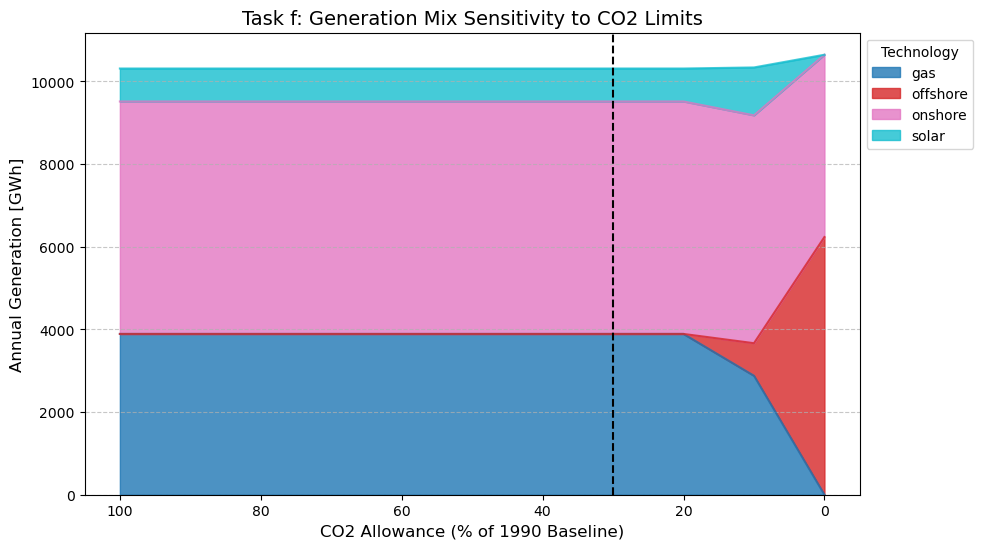

In [46]:
# Create a dedicated plot for Task f
# We divide by 1e6 to show TWh or 1e3 for GWh depending on your load size
df_gen_plot = df_gen.div(1e3) 

ax = df_gen_plot.plot.area(
    figsize=(10, 6),
    stacked=True,
    colormap='tab10', # Or use n.carriers.color if defined
    alpha=0.8
)

plt.title("Task f: Generation Mix Sensitivity to CO2 Limits", fontsize=14)
plt.xlabel("CO2 Allowance (% of 1990 Baseline)", fontsize=12)
plt.ylabel("Annual Generation [GWh]", fontsize=12)
plt.legend(title="Technology", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Invert x-axis to show the trend from 100% (easy) to 0% (hard)
plt.gca().invert_xaxis() 

# Add a vertical line for the Danish 2030 Target (70% reduction = 30% allowance)
plt.axvline(x=30, color='black', linestyle='--', label='Danish 2030 Target (30%)')
plt.show()

In energy system optimization, the "switching point" is the threshold where the model is forced to move from its preferred least-cost fossil fuel (Gas) to a more expensive, larger-scale renewable alternative.

100% to 40%: The gas area decreases linearly. The system is just doing "efficient" abatement—swapping out the easiest bits of gas for wind.

At 20% and below: There is a "profound" shift. Gas production hits a wall and is effectively forced out. To compensate, the onshore wind (the largest wedge) doesn't just grow; it explodes in capacity to cover the base load that gas used to handle.

The Switching Point is usually accompanied by a sharp jump in the $CO_2$ shadow price.Before the 30% mark, the "cost" to reduce carbon is relatively low.Once you hit the point where you have to start "over-building" wind to get rid of that last bit of gas, the shadow price (EUR/tonne) will likely spike.

### Question g

In [117]:
import numpy as np
import pypsa

# ============================================================
# NETWORK SETUP
# ============================================================
n_gas = pypsa.Network()
n_gas.set_snapshots(snapshots)

# ============================================================
# CARRIERS
# ============================================================
n_gas.add("Carrier", ["onshore", "offshore", "solar", "battery", "AC", "CH4"],
          overwrite=True)

# ============================================================
# BUSES — ELECTRICITY
# ============================================================
countries = ["DK2", "NO", "SE", "FI"]

for ctry in countries:
    n_gas.add("Bus", f"electricity_{ctry}", carrier="AC", v_nom=400)

# ============================================================
# BUSES — GAS
# ============================================================
for ctry in countries:
    n_gas.add("Bus", f"gas_{ctry}", carrier="CH4")

# ============================================================
# LOADS — ELECTRICITY
# ============================================================
n_gas.add("Load", "DK2 demand", bus="electricity_DK2", p_set=el_DK2.values)
n_gas.add("Load", "NO demand",  bus="electricity_NO",  p_set=el_NO.values)
n_gas.add("Load", "SE demand",  bus="electricity_SE",  p_set=el_SE.values)
n_gas.add("Load", "FI demand",  bus="electricity_FI",  p_set=el_FI.values)

# ============================================================
# GENERATORS — RENEWABLES
# ============================================================
data_cf = {
    "DK2": (onshore_DK, offshore_DK, pv_DK),
    "NO":  (onshore_NO, offshore_NO, pv_NO),
    "SE":  (onshore_SE, offshore_SE, pv_SE),
    "FI":  (onshore_FI, offshore_FI, pv_FI),
}

for ctry, (cf_on, cf_off, cf_pv) in data_cf.items():
    n_gas.add("Generator", f"onshore_{ctry}",
              bus=f"electricity_{ctry}", carrier="onshore",
              p_nom_extendable=True,
              capital_cost=costs.at["onwind", "capital_cost"],
              marginal_cost=costs.at["onwind", "marginal_cost"],
              p_max_pu=cf_on.values)

    n_gas.add("Generator", f"offshore_{ctry}",
              bus=f"electricity_{ctry}", carrier="offshore",
              p_nom_extendable=True,
              capital_cost=costs.at["offwind", "capital_cost"],
              marginal_cost=costs.at["offwind", "marginal_cost"],
              p_max_pu=cf_off.values)

    n_gas.add("Generator", f"solar_{ctry}",
              bus=f"electricity_{ctry}", carrier="solar",
              p_nom_extendable=True,
              capital_cost=costs.at["solar", "capital_cost"],
              marginal_cost=costs.at["solar", "marginal_cost"],
              p_max_pu=cf_pv.values)


# ============================================================
# GAS SUPPLY
# ============================================================
gas_cost = {"DK2": 50, "NO": 35, "SE": 60, "FI": 70}
max_gas_NO = 2000  # MW 

for ctry in countries:
    if ctry == "NO":
        n_gas.add("Generator", f"gas_supply_{ctry}",
                  bus=f"gas_{ctry}",
                  carrier="CH4",
                  p_nom=max_gas_NO,
                  p_nom_extendable=False,
                  marginal_cost=gas_cost[ctry])

# ============================================================
# CCGT — GAS → ELECTRICITY
# ============================================================
for ctry in countries:
    n_gas.add("Link", f"CCGT_{ctry}",
              bus0=f"gas_{ctry}",
              bus1=f"electricity_{ctry}",
              carrier="CH4",
              p_nom_extendable=True,
              efficiency=0.55,
              capital_cost=costs.at["CCGT", "capital_cost"],
             marginal_cost=costs.at["CCGT", "marginal_cost"])

# ============================================================
# ELECTRICITY INTERCONNECTIONS
# ============================================================
lines = {
    "DK2-NO": ("electricity_DK2", "electricity_NO", 1700),
    "DK2-SE": ("electricity_DK2", "electricity_SE", 740),
    "NO-SE":  ("electricity_NO",  "electricity_SE", 3500),
    "SE-FI":  ("electricity_SE",  "electricity_FI", 1200),
}

for name, (bus0, bus1, s_nom) in lines.items():
    n_gas.add("Line", name,
              bus0=bus0,
              bus1=bus1,
              carrier="AC",
              s_nom=s_nom,
              x=0.1)

# ============================================================
# GAS PIPELINES 
# ============================================================
gas_pipelines = {
    "NO-DK2": ("gas_NO", "gas_DK2"),
    "NO-SE":  ("gas_NO", "gas_SE"),
    "NO-FI":  ("gas_NO", "gas_FI"),
    "SE-FI":  ("gas_SE", "gas_FI"),
}

for name, (bus0, bus1) in gas_pipelines.items():
    n_gas.add("Link", name,
              bus0=bus0,
              bus1=bus1,
              carrier="CH4",
              efficiency=0.98,
              p_nom_extendable=True,
              p_min_pu=-1)

# ============================================================
# STORAGE — BATTERIES
# ============================================================
for ctry in countries:
    n_gas.add("StorageUnit", f"battery_{ctry}",
              bus=f"electricity_{ctry}",
              carrier="battery",
              p_nom_extendable=True,
              capital_cost=costs.at["battery storage", "capital_cost"],
              marginal_cost=costs.at["battery storage", "marginal_cost"],
              efficiency_store=0.9,
              efficiency_dispatch=0.9,
              max_hours=6)

# ============================================================
# STORAGE — GAS 
# ============================================================
for ctry in countries:
    n_gas.add("StorageUnit", f"gas_storage_{ctry}",
              bus=f"gas_{ctry}",
              carrier="CH4",
              p_nom_extendable=True,
              efficiency_store=0.95,
              efficiency_dispatch=0.95,
              max_hours=100)

# ============================================================
# SUMMARY
# ============================================================
print(f"Buses:         {len(n_gas.buses)}")
print(f"Loads:         {len(n_gas.loads)}")
print(f"Generators:    {len(n_gas.generators)}")
print(f"Links:         {len(n_gas.links)}")
print(f"Lines:         {len(n_gas.lines)}")
print(f"Storage Units: {len(n_gas.storage_units)}")
print(f"Snapshots:     {len(n_gas.snapshots)}")

Buses:         8
Loads:         4
Generators:    13
Links:         8
Lines:         4
Storage Units: 8
Snapshots:     8760


In [118]:
n_gas.optimize(solver_name="gurobi")

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 111.27it/s]

Set parameter Username
Set parameter LicenseID to value 2811262
Academic license - for non-commercial use only - expires 2027-04-21


Read LP format model from file C:\Users\vtato\AppData\Local\Temp\linopy-problem-a5dlosc_.lp
Reading time = 1.84 seconds
obj: 1007428 rows, 429268 columns, 2032616 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1007428 rows, 429268 columns and 2032616 nonzeros
Model fingerprint: 0xbab4f782
Coefficient statistics:
  Matrix range     [7e-05, 1e+02]
  Objective range  [1e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 3e+04]
Presolve removed 709316 rows and 174936 columns
Presolve time: 1.56s
Presolved: 298112 rows, 254332 columns, 859296 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.24s

Barrier statistics:
 Dense cols : 20
 AA' NZ     : 6.663e+05
 Factor NZ  : 5

('ok', 'optimal')

In [49]:
n_gas.links['p_nom_extendable']

name
CCGT_DK2    True
CCGT_NO     True
CCGT_SE     True
CCGT_FI     True
NO-DK2      True
NO-SE       True
NO-FI       True
SE-FI       True
Name: p_nom_extendable, dtype: bool

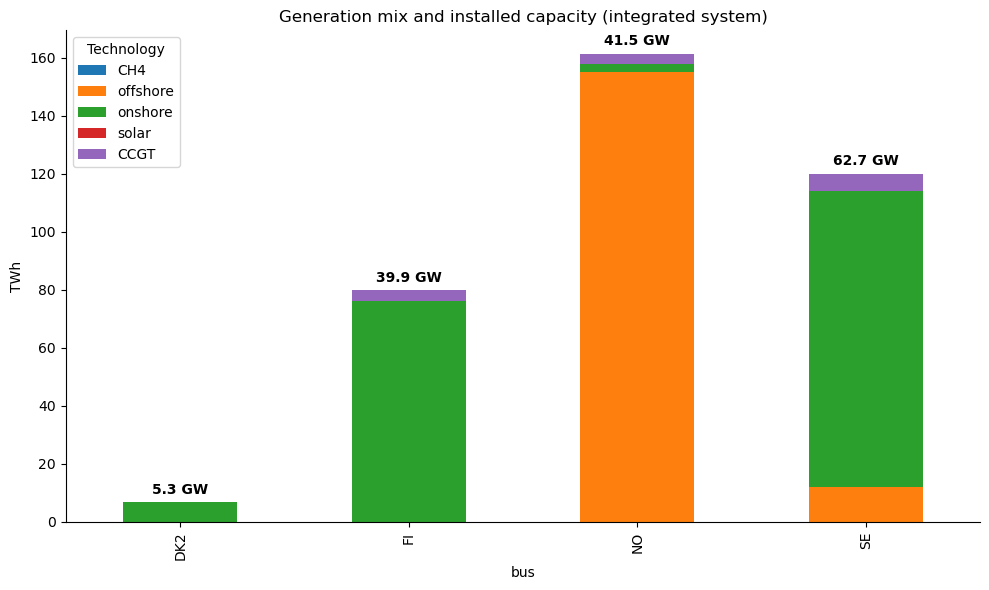

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. GENERATION (TWh) — ELECTRICITY ONLY
# ============================================================
gen = n_gas.generators_t.p

gen_bus = n_gas.generators.bus
gen_tech = n_gas.generators.carrier

gen.columns = pd.MultiIndex.from_arrays([gen_bus, gen_tech])

gen_multi = gen.T.groupby(level=[0,1]).sum().T
gen_multi_annual = gen_multi.sum() / 1e6  # TWh

gen_plot = gen_multi_annual.unstack().fillna(0)

# ✔ KEEP ONLY ELECTRICITY BUSES
gen_plot = gen_plot.loc[gen_plot.index.str.startswith("electricity_")]
gen_plot.index = gen_plot.index.str.replace("electricity_", "")

# ============================================================
# 2. CCGT (TWh) — FROM LINKS
# ============================================================
ccgt = n_gas.links_t.p1.filter(like="CCGT").abs()

ccgt.columns = ccgt.columns.str.replace("CCGT_", "")
ccgt_annual = ccgt.sum() / 1e6  # TWh

gen_plot["CCGT"] = ccgt_annual

# ============================================================
# 3. CAPACITY (GW)
# ============================================================
cap_gen = n_gas.generators.p_nom_opt.copy()

cap_gen.index = pd.MultiIndex.from_arrays(
    [n_gas.generators.bus, n_gas.generators.carrier]
)

# ✔ KEEP ONLY ELECTRICITY BUS
cap_gen = cap_gen.loc[
    cap_gen.index.get_level_values(0).str.startswith("electricity_")
]

cap_gen_bus = cap_gen.groupby(level=0).sum() / 1000
cap_gen_bus.index = cap_gen_bus.index.str.replace("electricity_", "")

# ============================================================
# CCGT CAPACITY
# ============================================================
cap_ccgt = n_gas.links.p_nom_opt.filter(like="CCGT") / 1000
cap_ccgt.index = cap_ccgt.index.str.replace("CCGT_", "")

cap_by_bus = cap_gen_bus.add(cap_ccgt, fill_value=0)

# align exactly with plot
cap_by_bus = cap_by_bus.reindex(gen_plot.index).fillna(0)

# ============================================================
# 4. PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10,6))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# stacked generation
gen_plot.plot(kind="bar", stacked=True, ax=ax)

# ============================================================
# capacity labels
# ============================================================
for i, country in enumerate(gen_plot.index):
    total_cap = float(cap_by_bus.loc[country])
    total_gen = gen_plot.loc[country].sum()

    ax.text(
        i,
        total_gen + 3,
        f"{total_cap:.1f} GW",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# STYLE
# ============================================================
plt.ylabel("TWh")
plt.title("Generation mix and installed capacity (integrated system)")
plt.legend(title="Technology")
plt.tight_layout()

plt.savefig("genmix_final.png", dpi=300)
plt.show()

In [ ]:
print(n_gas.generators[["p_nom_opt"]])
print(n_gas.lines[["s_nom_opt"]])
print(n_gas.links[["p_nom_opt"]])
gas_links = n_gas.links.index[n_gas.links.carrier == "CH4"]
gas_flow = n_gas.links_t.p0[gas_links].abs().sum().sum()


                  p_nom_opt
name                       
onshore_DK2     5282.257710
offshore_DK2       0.000000
solar_DK2          0.000000
onshore_NO      2865.947046
offshore_NO    31848.922358
solar_NO           0.000000
onshore_SE     47974.203496
offshore_SE     3396.242002
solar_SE           0.000000
onshore_FI     29228.265920
offshore_FI        0.000000
solar_FI           0.000000
gas_supply_NO   2000.000000
        s_nom_opt
name             
DK2-NO     1700.0
DK2-SE      740.0
NO-SE      3500.0
SE-FI      1200.0
             p_nom_opt
name                  
CCGT_DK2  0.000000e+00
CCGT_NO   6.826015e+03
CCGT_SE   1.136540e+04
CCGT_FI   1.069804e+04
NO-DK2    0.000000e+00
NO-SE     1.455389e+06
NO-FI     1.448563e+06
SE-FI     1.437647e+06


In [52]:
n_gas.storage_units


,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge,cyclic_state_of_charge_per_period,max_hours,efficiency_store,efficiency_dispatch,standing_loss,inflow,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
battery_DK2,electricity_DK2,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,6.0,0.90,0.90,0.0,0.0,13809.191876
battery_NO,electricity_NO,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,6.0,0.90,0.90,0.0,0.0,71829.684378
battery_SE,electricity_SE,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,6.0,0.90,0.90,0.0,0.0,49151.809621
battery_FI,electricity_FI,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,6.0,0.90,0.90,0.0,0.0,35722.318708
gas_storage_DK2,gas_DK2,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,100.0,0.95,0.95,0.0,0.0,0.000000
gas_storage_NO,gas_NO,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,100.0,0.95,0.95,0.0,0.0,0.000000
gas_storage_SE,gas_SE,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,100.0,0.95,0.95,0.0,0.0,0.000000
gas_storage_FI,gas_FI,PQ,,0.0,0.0,True,0.0,inf,NaN,-1.0,...,False,NaN,False,False,100.0,0.95,0.95,0.0,0.0,0.000000


In [53]:
no_dk2_flow = n_gas.links_t.p0["NO-DK2"]
print("Mean flow (MW):", no_dk2_flow.mean())
print("Max flow (MW):", no_dk2_flow.max())
print("Min flow (MW):", no_dk2_flow.min())
print("Std:", no_dk2_flow.std())

Mean flow (MW): 0.0
Max flow (MW): 0.0
Min flow (MW): 0.0
Std: 0.0


In [54]:
import pandas as pd

# ============================================================
# 1. ELECTRICITY GENERATION (TWh)
# ============================================================
elec_gen = n_gas.generators_t.p

electricity_MWh = elec_gen.sum().sum()
electricity_TWh = electricity_MWh / 1e6

# ============================================================
# 2. CCGT OUTPUT (GAS → ELECTRICITY) (TWh)
# ============================================================
ccgt = n_gas.links_t.p1.filter(like="CCGT")

ccgt_energy_MWh = ccgt.sum().sum()
ccgt_energy_TWh = n_gas.links_t.p1.filter(like="CCGT").abs().sum().sum() / 1e6

# ============================================================
# 3. GAS PIPELINE TRANSPORT (TWh equivalent)
# ============================================================
gas_pipes = ["NO-DK2", "NO-SE", "NO-FI", "SE-FI"]

gas_flow = n_gas.links_t.p0[gas_pipes].abs()

gas_energy_MWh = gas_flow.sum().sum()
gas_energy_TWh = gas_energy_MWh / 1e6

# ============================================================
# 4. RESULTS
# ============================================================
print("Electricity generation (TWh):", electricity_TWh)
print("CCGT electricity output (TWh):", ccgt_energy_TWh)
print("Gas transported (TWh equivalent):", gas_energy_TWh)

# ============================================================
# 5. KEY INSIGHT RATIOS (optional but very useful)
# ============================================================
print("\n--- SYSTEM COMPARISON ---")
print("CCGT share of electricity generation:",
      100 * ccgt_energy_TWh / electricity_TWh, "%")

print("Gas transport vs electricity generation ratio:",
      gas_energy_TWh / electricity_TWh)

Electricity generation (TWh): 354.8360237764934
CCGT electricity output (TWh): 13.324903976229384
Gas transported (TWh equivalent): 3634.8124972007054

--- SYSTEM COMPARISON ---
CCGT share of electricity generation: 3.755228636149572 %
Gas transport vs electricity generation ratio: 10.243640029881032


In [55]:
n_gas.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
CCGT_DK2,gas_DK2,electricity_DK2,,CH4,0.55,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.000000e+00
CCGT_NO,gas_NO,electricity_NO,,CH4,0.55,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,6.826015e+03
CCGT_SE,gas_SE,electricity_SE,,CH4,0.55,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.136540e+04
CCGT_FI,gas_FI,electricity_FI,,CH4,0.55,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.069804e+04
NO-DK2,gas_NO,gas_DK2,,CH4,0.98,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.000000e+00
NO-SE,gas_NO,gas_SE,,CH4,0.98,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.455389e+06
NO-FI,gas_NO,gas_FI,,CH4,0.98,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.448563e+06
SE-FI,gas_SE,gas_FI,,CH4,0.98,True,0,inf,0.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.437647e+06


In [56]:
ccgt_elec = n_gas.links_t.p1.filter(like="CCGT")

ccgt_energy_TWh = ccgt_elec.sum().sum() / 1e6
print(ccgt_energy_TWh)

-13.324903976229384


In [57]:
gas_input = -n_gas.links_t.p0.filter(like="CCGT")

gas_energy_TWh = gas_input.sum().sum() / 1e6
print(gas_energy_TWh)

-24.227098138598883


In [58]:
gas_flow = n_gas.links_t.p0.filter(like="NO-")

gas_transport_TWh = gas_flow.abs().sum().sum() / 1e6
print(gas_transport_TWh)

2429.859072126033


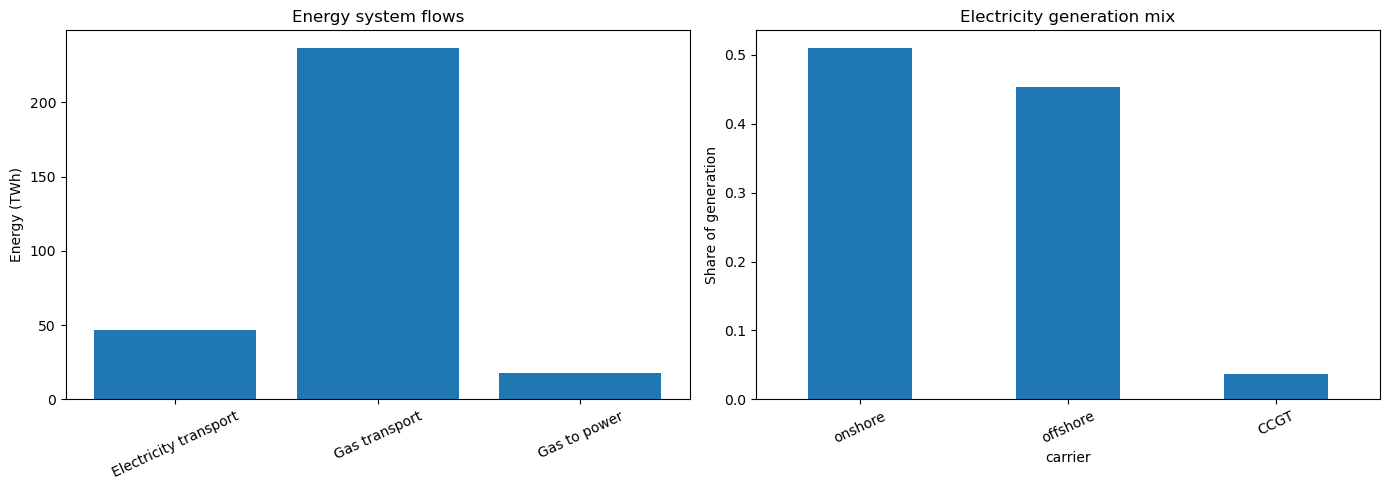

In [62]:
import matplotlib.pyplot as plt

# =========================
# FLOWS (energy system level)
# =========================
gas_transport = 236616222.42950988
gas_to_power = 18006922.79239866
electricity_transport = 46944282.57530676

# Convert to TWh for readability
gas_transport /= 1e6
gas_to_power /= 1e6
electricity_transport /= 1e6

flow_labels = [
    "Electricity transport",
    "Gas transport",
    "Gas to power"
]

flow_values = [
    electricity_transport,
    gas_transport,
    gas_to_power
]

# =========================
# GENERATION MIX
# =========================
mix = gen_plot.sum()          # sum across all countries
mix = mix[mix > 0]            # drop zeros
mix = mix / mix.sum()         # normalise to shares

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- LEFT: ENERGY FLOWS ----
axes[0].bar(flow_labels, flow_values)
axes[0].set_title("Energy system flows")
axes[0].set_ylabel("Energy (TWh)")
axes[0].tick_params(axis='x', rotation=25)

# ---- RIGHT: GENERATION MIX ----
mix.sort_values(ascending=False).plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Electricity generation mix")
axes[1].set_ylabel("Share of generation")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()

# ✅ SAVE FIGURE (prima di show)
plt.savefig("energy_system_flows.png", dpi=300, bbox_inches='tight')

plt.show()

The figure decomposes the energy system into cross-border energy flows and electricity generation. While the gas network dominates inter-country energy transport, electricity generation is largely based on renewable sources, with gas-fired generation playing a supporting role for system reliability.

In [ ]:
n_gas.export_to_netcdf("results_task_G.nc")
print("Task G saved.")

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'results_task_G.nc contains: sub_networks, storage_units, generators, buses, lines, carriers, global_constraints, loads, links


Task G saved.


**Task h - Taking the system from task g**

In [80]:
# ============================================================
# TASK h — CO2 Shadow Price (continuing from Task g, n_gas)
# ============================================================
gas_intensity = costs.at["gas", "CO2 intensity"]
baseline_1990 = 3.469e6  # max possible emissions: gas_supply_NO at 100% CF
allowances    = np.linspace(1.0, 0.0, 11)
system_costs_h, co2_prices_h, gen_mix_h = [], [], []
print("Setup done. Baseline:", baseline_1990/1e6, "MtCO2/yr")
print("Allowances:", allowances * 100)



Setup done. Baseline: 3.469 MtCO2/yr
Allowances: [100.  90.  80.  70.  60.  50.  40.  30.  20.  10.   0.]


In [81]:
n_test = pypsa.Network("results_task_G.nc")
n_test.carriers.at["CH4", "co2_emissions"] = gas_intensity
n_test.add("GlobalConstraint", "CO2Limit",
        type="primary_energy",
        constant=0,
        carrier_attribute="co2_emissions",
        sense="<=",
        overwrite=True)
n_test.optimize(solver_name="gurobi")
print("CO2 price at 0% allowance:", abs(n_test.global_constraints.at["CO2Limit", "mu"]))

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.7)
            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks
Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Wri

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

Solved in 69079 iterations and 42.35 seconds (21.92 work units)


INFO:gurobipy:Solved in 69079 iterations and 42.35 seconds (21.92 work units)


Optimal objective  2.982966889e+10


INFO:gurobipy:Optimal objective  2.982966889e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429268 primals, 1007429 duals
Objective: 2.98e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


CO2 price at 0% allowance: 0.0


In [82]:
#First half loop

for limit in allowances[:6]:
    n_h = pypsa.Network("results_task_G.nc")
    n_h.carriers.at["CH4", "co2_emissions"] = gas_intensity

    current_cap = baseline_1990 * limit
    n_h.add("GlobalConstraint", "CO2Limit",
            type="primary_energy",
            constant=current_cap,
            carrier_attribute="co2_emissions",
            sense="<=",
            overwrite=True)

    n_h.optimize(solver_name="gurobi")

    system_costs_h.append(n_h.objective)
    co2_prices_h.append(n_h.global_constraints.at["CO2Limit", "mu"])

    gen = n_h.generators_t.p.T.groupby(n_h.generators.carrier).sum().T.sum()
    gen["CCGT"] = n_h.links_t.p1.filter(like="CCGT").abs().sum().sum()
    gen_mix_h.append(gen)

    print(f"Allowance {limit*100:.0f}%  |  Cost: {n_h.objective/1e9:.3f} B EUR  |  CO2 price: {abs(n_h.global_constraints.at['CO2Limit','mu']):.1f} EUR/t")

print(f"Half done. {len(co2_prices_h)} solves completed.")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.7)
            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks
Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Wri

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

Solved in 69079 iterations and 39.38 seconds (21.92 work units)


INFO:gurobipy:Solved in 69079 iterations and 39.38 seconds (21.92 work units)


Optimal objective  2.982966889e+10


INFO:gurobipy:Optimal objective  2.982966889e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429268 primals, 1007429 duals
Objective: 2.98e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Allowance 50%  |  Cost: 29.830 B EUR  |  CO2 price: 0.0 EUR/t
Half done. 6 solves completed.


In [83]:
#Second half of the loop

for limit in allowances[6:]:
    n_h = pypsa.Network("results_task_G.nc")
    n_h.carriers.at["CH4", "co2_emissions"] = gas_intensity

    current_cap = baseline_1990 * limit
    n_h.add("GlobalConstraint", "CO2Limit",
            type="primary_energy",
            constant=current_cap,
            carrier_attribute="co2_emissions",
            sense="<=",
            overwrite=True)

    n_h.optimize(solver_name="gurobi")

    system_costs_h.append(n_h.objective)
    co2_prices_h.append(n_h.global_constraints.at["CO2Limit", "mu"])

    gen = n_h.generators_t.p.T.groupby(n_h.generators.carrier).sum().T.sum()
    gen["CCGT"] = n_h.links_t.p1.filter(like="CCGT").abs().sum().sum()
    gen_mix_h.append(gen)

    print(f"Allowance {limit*100:.0f}%  |  Cost: {n_h.objective/1e9:.3f} B EUR  |  CO2 price: {abs(n_h.global_constraints.at['CO2Limit','mu']):.1f} EUR/t")

print(f"All done. {len(co2_prices_h)} solves completed.")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.7)
            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks
Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Wri

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2811262


INFO:gurobipy:Set parameter LicenseID to value 2811262


...

Solved in 69079 iterations and 47.21 seconds (21.92 work units)


INFO:gurobipy:Solved in 69079 iterations and 47.21 seconds (21.92 work units)


Optimal objective  2.982966889e+10


INFO:gurobipy:Optimal objective  2.982966889e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429268 primals, 1007429 duals
Objective: 2.98e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Allowance 0%  |  Cost: 29.830 B EUR  |  CO2 price: 0.0 EUR/t
All done. 11 solves completed.


               System Cost (B EUR)  CO2 Price (EUR/t)
Allowance (%)                                        
100.0                        29.83                0.0
90.0                         29.83                0.0
80.0                         29.83                0.0
70.0                         29.83                0.0
60.0                         29.83                0.0
50.0                         29.83                0.0
40.0                         29.83                0.0
30.0                         29.83                0.0
20.0                         29.83                0.0
10.0                         29.83                0.0
0.0                          29.83                0.0


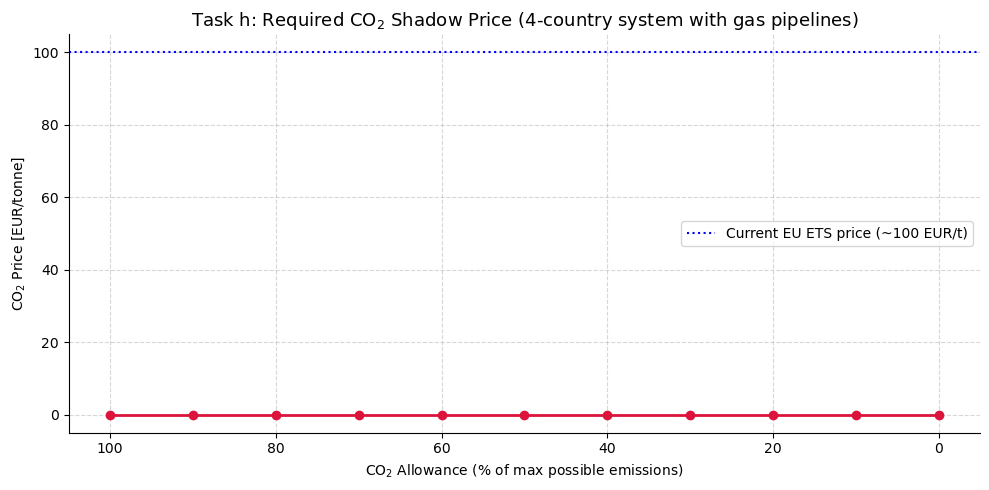

In [84]:
#Results

results_h = pd.DataFrame({
    "System Cost (B EUR)": np.array(system_costs_h) / 1e9,
    "CO2 Price (EUR/t)":   np.abs(co2_prices_h),
    "Allowance (%)":       allowances * 100
}).set_index("Allowance (%)")

df_gen_h = pd.DataFrame(gen_mix_h, index=allowances * 100)
print(results_h.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(allowances * 100, np.abs(co2_prices_h),
        marker="o", color="crimson", linewidth=2)
ax.axhline(y=100, color="blue", linestyle=":",
           label="Current EU ETS price (~100 EUR/t)")
ax.invert_xaxis()
ax.set_title("Task h: Required CO$_2$ Shadow Price (4-country system with gas pipelines)", fontsize=13)
ax.set_xlabel("CO$_2$ Allowance (% of max possible emissions)")
ax.set_ylabel("CO$_2$ Price [EUR/tonne]")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Task - i**

In [107]:
# ============================================================
# SECTION i — HEATING SECTOR
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1 — LOAD AMBIENT TEMPERATURES
# ============================================================
def load_temperature(country, snapshots):
    df = pd.read_csv(f"i/{country}ambientT.csv")
    df['valid_time'] = pd.to_datetime(df['valid_time'], utc=True).dt.tz_localize(None)
    df.set_index('valid_time', inplace=True)
    T_celsius = df['t2m'] - 273.15 
    return T_celsius.reindex(snapshots).ffill()

temperature = {
    "DK2": load_temperature("DK2", snapshots),
    "NO":  load_temperature("NO",  snapshots),
    "SE":  load_temperature("SE",  snapshots),
    "FI":  load_temperature("FI",  snapshots),
}

for ctry, T in temperature.items():
    print(f"{ctry} | Jan 1 00:00 → {T.iloc[0]:.2f} °C  |  "
          f"Min: {T.min():.1f} °C  Max: {T.max():.1f} °C")

# ============================================================
# STEP 2 — COMPUTE HDH
# ============================================================
T_threshold = 17  # °C

HDH = {}
for ctry, T in temperature.items():
    HDH[ctry] = (T_threshold - T).clip(lower=0)
    print(f"{ctry} | Annual HDH sum: {HDH[ctry].sum():.0f} °C·h")

# ============================================================
# STEP 3 — LOAD ANNUAL HEAT DEMAND FROM EUROSTAT
# ============================================================
heat_raw = pd.read_csv("i/annualheatdemandgwh.csv")

country_map = {
    "Denmark": "DK2",
    "Norway":  "NO",
    "Sweden":  "SE",
    "Finland": "FI",
}

heat_raw["node"] = heat_raw["geo"].map(country_map)
heat_annual = heat_raw.set_index("node")["OBS_VALUE"] * 1e3  # GWh → MWh

# DK2 is 40% of Denmark
heat_annual["DK2"] = heat_annual["DK2"] * 0.40

# Norway: Eurostat only captures district heat,
# so we scale from Finland using HDH ratio
heat_annual["NO"] = heat_annual["FI"] * (HDH["NO"].sum() / HDH["FI"].sum())

# ============================================================
# STEP 4 — SPLIT INTO SPACE HEAT vs HOT WATER
# Nordic literature assumptions:
#   Space heating = 70% of total household heat
#   Water heating = 15% of total household heat
#   Remaining 15% (cooking/appliances) excluded
# ============================================================
space_heat_fraction = 0.70
hot_water_fraction  = 0.15

space_heat_MWh = (heat_annual * space_heat_fraction).to_dict()
water_heat_MWh = (heat_annual * hot_water_fraction).to_dict()

# ============================================================
# STEP 5 — BUILD HEATING DEMAND TIME SERIES
# heat_demand(t) = scaling_factor * HDH(t) + hot_water_hourly
# ============================================================
heat_demand_ts = {}

for ctry in countries:
    Q_space          = space_heat_MWh[ctry]
    Q_water          = water_heat_MWh[ctry]
    hdh              = HDH[ctry]

    scaling_factor   = Q_space / hdh.sum()        # MW/°C
    hot_water_hourly = Q_water / len(snapshots)  

    heat_demand_ts[ctry] = scaling_factor * hdh + hot_water_hourly

    total    = heat_demand_ts[ctry].sum()
    expected = Q_space + Q_water
    print(f"{ctry} | Total: {total/1e6:.2f} TWh  "
          f"(expected {expected/1e6:.2f} TWh) | "
          f"Peak: {heat_demand_ts[ctry].max():.0f} MW | "
          f"Min: {heat_demand_ts[ctry].min():.0f} MW")

# ============================================================
# STEP 6 — Heating Demand Plot
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, ctry in zip(axes, countries):
    ax.plot(heat_demand_ts[ctry].values, linewidth=0.5)
    ax.set_ylabel(f"{ctry} (MW)")
    ax.set_title(f"{ctry} heating demand 2024")
plt.suptitle("Heating Demand Time Series 2024", fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 7 — ADD TO n_gas: CARRIER + BUSES + LOADS
# ============================================================
n_gas.add("Carrier", "heat", overwrite=True)

for ctry in countries:
    n_gas.add("Bus", f"heat_{ctry}", carrier="heat", overwrite=True)

for ctry in countries:
    n_gas.add("Load", f"{ctry} heat demand",
              bus=f"heat_{ctry}",
              p_set=heat_demand_ts[ctry].values,
              overwrite=True)

# ============================================================
# STEP 9 — TEMPERATURE-DEPENDENT COP
# COP(T) = 6.81 - 0.121*(T_sink - T_source) + 0.00063*(T_sink - T_source)^2
# T_sink = 55°C (typical radiator flow temperature)
# T_source = hourly ambient temperature from ERA5
# ============================================================
T_sink = 55  # °C, typical district heating flow temperature

cop_ts = {}
for ctry in countries:
    T = temperature[ctry]
    delta_T = T_sink - T
    cop = 6.81 - 0.121 * delta_T + 0.00063 * delta_T**2
    cop_ts[ctry] = cop.clip(lower=1.0, upper=5.0)
    print(f"{ctry} | Mean COP: {cop_ts[ctry].mean():.2f} | "
          f"Min: {cop_ts[ctry].min():.2f} | "
          f"Max: {cop_ts[ctry].max():.2f}")

for ctry in countries:
    n_gas.add("Link", f"heat_pump_{ctry}",
              bus0=f"electricity_{ctry}",
              bus1=f"heat_{ctry}",
              carrier="heat",
              p_nom_extendable=True,
              efficiency=cop_ts[ctry].values,
              capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
              marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"],
              overwrite=True)

# ============================================================
# STEP 8 — GAS BOILERS
# ============================================================
for ctry in countries:
    n_gas.add("Link", f"gas_boiler_{ctry}",
              bus0=f"gas_{ctry}",
              bus1=f"heat_{ctry}",
              carrier="heat",
              p_nom_extendable=True,
              efficiency=0.90,
              capital_cost=costs.at["central gas boiler", "capital_cost"],
              marginal_cost=costs.at["central gas boiler", "marginal_cost"],
              overwrite=True)

# ============================================================
# STEP 9 — THERMAL STORAGE
# ============================================================
for ctry in countries:
    n_gas.add("StorageUnit", f"heat_storage_{ctry}",
              bus=f"heat_{ctry}",
              carrier="heat",
              p_nom_extendable=True,
              capital_cost=costs.at["central water tank charger", "capital_cost"],
              efficiency_store=0.99,
              efficiency_dispatch=0.99,
              standing_loss=0.01,
              max_hours=12,
              overwrite=True)

print(f"\nNetwork summary after adding heating sector:")
print(f"  Heat buses:      {len(n_gas.buses[n_gas.buses.carrier == 'heat'])}")
print(f"  Heat loads:      {len(n_gas.loads[n_gas.loads.bus.str.startswith('heat')])}")
print(f"  Heat pumps:      {len(n_gas.links[n_gas.links.index.str.startswith('heat_pump')])}")
print(f"  Gas boilers:     {len(n_gas.links[n_gas.links.index.str.startswith('gas_boiler')])}")
print(f"  Thermal storage: {len(n_gas.storage_units[n_gas.storage_units.bus.str.startswith('heat')])}")

# ============================================================
# STEP 10 — CO-OPTIMISE ALL THREE SECTORS TOGETHER
# ============================================================

# STEP 10 — Reload clean n_gas and add heating sector components already defined above
n_gas_i = pypsa.Network("results_task_G.nc")

# Copy over all heating components from n_gas to n_gas_i
for ctry in countries:
    n_gas_i.add("Carrier", "heat", overwrite=True)
    n_gas_i.add("Bus", f"heat_{ctry}", carrier="heat", overwrite=True)
    n_gas_i.add("Load", f"{ctry} heat demand",
                bus=f"heat_{ctry}",
                p_set=heat_demand_ts[ctry].values)
    n_gas_i.add("Link", f"heat_pump_{ctry}",
                bus0=f"electricity_{ctry}",
                bus1=f"heat_{ctry}",
                carrier="heat",
                p_nom_extendable=True,
                efficiency=cop_ts[ctry].values,
                capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
                marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"])
    n_gas_i.add("Link", f"gas_boiler_{ctry}",
                bus0=f"gas_{ctry}",
                bus1=f"heat_{ctry}",
                carrier="heat",
                p_nom_extendable=True,
                efficiency=0.90,
                capital_cost=costs.at["central gas boiler", "capital_cost"],
                marginal_cost=costs.at["central gas boiler", "marginal_cost"])
    n_gas_i.add("StorageUnit", f"heat_storage_{ctry}",
                bus=f"heat_{ctry}",
                carrier="heat",
                p_nom_extendable=True,
                capital_cost=costs.at["central water tank charger", "capital_cost"],
                efficiency_store=0.99,
                efficiency_dispatch=0.99,
                standing_loss=0.01,
                max_hours=12)

n_gas_i.consistency_check()
n_gas_i.optimize(solver_name="gurobi")

DK2 | Jan 1 00:00 → 5.51 °C  |  Min: -12.3 °C  Max: 26.6 °C
NO | Jan 1 00:00 → -10.44 °C  |  Min: -27.4 °C  Max: 24.7 °C
SE | Jan 1 00:00 → -16.67 °C  |  Min: -29.9 °C  Max: 28.0 °C
FI | Jan 1 00:00 → -20.82 °C  |  Min: -35.8 °C  Max: 30.0 °C
DK2 | Annual HDH sum: 69217 °C·h
NO | Annual HDH sum: 129884 °C·h
SE | Annual HDH sum: 117154 °C·h
FI | Annual HDH sum: 115097 °C·h
DK2 | Total: 6.64 TWh  (expected 6.64 TWh) | Peak: 2452 MW | Min: 134 MW
NO | Total: 17.50 TWh  (expected 17.50 TWh) | Peak: 5280 MW | Min: 352 MW
SE | Total: 25.87 TWh  (expected 25.87 TWh) | Peak: 9042 MW | Min: 521 MW
FI | Total: 15.50 TWh  (expected 15.50 TWh) | Peak: 6167 MW | Min: 312 MW
DK2 | Mean COP: 2.63 | Min: 1.52 | Max: 3.88
NO | Mean COP: 2.23 | Min: 1.12 | Max: 3.72
SE | Mean COP: 2.34 | Min: 1.08 | Max: 4.00
FI | Mean COP: 2.39 | Min: 1.02 | Max: 4.18


C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1496361721.py:107: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators



Network summary after adding heating sector:
  Heat buses:      4
  Heat loads:      4
  Heat pumps:      4
  Gas boilers:     4
  Thermal storage: 4


c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 72.75it/s]


Set parameter Username
Set parameter LicenseID to value 2811262
Academic license - for non-commercial use only - expires 2027-04-21
Read LP format model from file C:\Users\vtato\AppData\Local\Temp\linopy-problem-1col_g2i.lp
Reading time = 2.69 seconds
obj: 1427921 rows, 604480 columns, 2917388 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1427921 rows, 604480 columns and 2917388 nonzeros
Model fingerprint: 0x726fa019
Coefficient statistics:
  Matrix range     [7e-05, 1e+02]
  Objective range  [1e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 4e+07]
Presolve removed 989653 rows and 174952 columns
Presolve time: 1.91s
Presolved: 438268 rows, 429528 columns, 1314792 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and ba

('ok', 'optimal')

In [108]:
# ============================================================
# RESULTS ANALYSIS — SECTION i
# ============================================================

# 1. SYSTEM COST
print(f"Total system cost: {n_gas_i.objective/1e9:.2f} Billion EUR/year")

# 2. INSTALLED CAPACITIES — HEAT SECTOR
print("\n--- Heat pump capacity (MW) ---")
print(n_gas.links.p_nom_opt[n_gas_i.links.index.str.startswith("heat_pump")].round(1))

print("\n--- Gas boiler capacity (MW) ---")
print(n_gas.links.p_nom_opt[n_gas_i.links.index.str.startswith("gas_boiler")].round(1))

print("\n--- Thermal storage capacity (MW) ---")
print(n_gas.storage_units.p_nom_opt[
    n_gas_i.storage_units.index.str.startswith("heat_storage")].round(1))

# 3. ANNUAL ENERGY
heat_pump_energy = n_gas_i.links_t.p1.filter(like="heat_pump").abs().sum() / 1e6
boiler_energy    = n_gas_i.links_t.p1.filter(like="gas_boiler").abs().sum() / 1e6

print("\n--- Annual heat from heat pumps (TWh) ---")
print(heat_pump_energy.round(2))
print("\n--- Annual heat from gas boilers (TWh) ---")
print(boiler_energy.round(2))

# 4. SHARE OF HEAT SUPPLY PER COUNTRY
print("\n--- Heat supply share per country ---")
for ctry in countries:
    hp  = n_gas_i.links_t.p1[f"heat_pump_{ctry}"].abs().sum()
    gb  = n_gas_i.links_t.p1[f"gas_boiler_{ctry}"].abs().sum()
    tot = hp + gb
    print(f"{ctry}: heat pump {hp/tot*100:.1f}%  |  gas boiler {gb/tot*100:.1f}%")

# 5. ELECTRICITY CONSUMED BY HEAT PUMPS
hp_elec = n_gas_i.links_t.p0.filter(like="heat_pump").sum() / 1e6
print("\n--- Electricity consumed by heat pumps (TWh) ---")
print(hp_elec.round(2))

# 6. GENERATOR + CCGT CAPACITIES
print("\n--- Generator capacities (GW) ---")
print(n_gas_i.generators.p_nom_opt.div(1e3).round(2))

print("\n--- CCGT capacities (GW) ---")
ccgt = n_gas_i.links.p_nom_opt[n_gas_i.links.index.str.startswith("CCGT")]
print(ccgt.div(1e3).round(2))

# 7. PLOT: HEAT SUPPLY MIX PER COUNTRY
import matplotlib.pyplot as plt

hp_vals = [n_gas_i.links_t.p1[f"heat_pump_{c}"].abs().sum()/1e6 for c in countries]
gb_vals = [n_gas_i.links_t.p1[f"gas_boiler_{c}"].abs().sum()/1e6 for c in countries]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(countries, hp_vals, label="Heat pump", color="steelblue")
ax.bar(countries, gb_vals, bottom=hp_vals, label="Gas boiler", color="tomato")
ax.set_ylabel("Annual heat delivered (TWh)")
ax.set_title("Heat supply mix by country")
ax.legend()
plt.tight_layout()
plt.show()

# 8. PLOT: WINTER WEEK DISPATCH
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
winter = slice("2024-01-15", "2024-01-22")

for ax, ctry in zip(axes, countries):
    hp  = n_gas_i.links_t.p1[f"heat_pump_{ctry}"].abs().loc[winter]
    gb  = n_gas_i.links_t.p1[f"gas_boiler_{ctry}"].abs().loc[winter]
    dem = pd.Series(heat_demand_ts[ctry].values,
                    index=n_gas_i.snapshots).loc[winter]
    x   = range(len(hp))

    ax.plot(dem.values, 'k--', linewidth=1, label="Demand")
    ax.stackplot(x,
                 hp.values,
                 gb.values,
                 labels=["Heat pump", "Gas boiler"],
                 colors=["steelblue", "tomato"],
                 alpha=0.7)
    ax.set_ylabel(f"{ctry} (MW)")
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Heat dispatch — Week January 2024", fontsize=13)
plt.tight_layout()
plt.show()

# 9. Whole year - Monthly Heat Dispatch 
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for ax, ctry in zip(axes, countries):
    hp  = n_gas_i.links_t.p1[f"heat_pump_{ctry}"].abs().resample("M").sum() / 1e3
    gb  = n_gas_i.links_t.p1[f"gas_boiler_{ctry}"].abs().resample("M").sum() / 1e3
    months = range(len(hp))

    ax.bar(months, hp.values, label="Heat pump", color="steelblue", alpha=0.8)
    ax.bar(months, gb.values, bottom=hp.values, label="Gas boiler", color="tomato", alpha=0.8)
    ax.set_ylabel(f"{ctry} (GWh)")
    ax.set_xticks(months)
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=8)
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Monthly Heat Dispatch — Full Year 2024", fontsize=13)
plt.tight_layout()
plt.show()

Total system cost: 30.13 Billion EUR/year

--- Heat pump capacity (MW) ---
name
heat_pump_DK2     0.0
heat_pump_SE      0.0
gas_boiler_DK2    0.0
gas_boiler_SE     0.0
Name: p_nom_opt, dtype: float64

--- Gas boiler capacity (MW) ---
name
heat_pump_NO     0.0
heat_pump_FI     0.0
gas_boiler_NO    0.0
gas_boiler_FI    0.0
Name: p_nom_opt, dtype: float64

--- Thermal storage capacity (MW) ---
name
heat_storage_DK2    0.0
heat_storage_NO     0.0
heat_storage_SE     0.0
heat_storage_FI     0.0
Name: p_nom_opt, dtype: float64

--- Annual heat from heat pumps (TWh) ---
name
heat_pump_DK2    0.0
heat_pump_NO     0.0
heat_pump_SE     0.0
heat_pump_FI     0.0
dtype: float64

--- Annual heat from gas boilers (TWh) ---
name
gas_boiler_DK2     6.68
gas_boiler_NO     17.52
gas_boiler_SE     25.90
gas_boiler_FI     15.52
dtype: float64

--- Heat supply share per country ---
DK2: heat pump 0.0%  |  gas boiler 100.0%
NO: heat pump 0.0%  |  gas boiler 100.0%
SE: heat pump 0.0%  |  gas boiler 100.0%
FI:

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\3690374717.py:62: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\3690374717.py:87: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\3690374717.py:93: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\3690374717.py:94: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\3690374717.py:93: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\3690374717.py:94: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ip

In [109]:
# Electricity, Gas and Heat dispatch - January 2024
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
week = slice("2024-01-15", "2024-01-22")

# --- ELECTRICITY SECTOR ---
el_gen = n_gas.generators_t.p.loc[week]
el_grouped = el_gen.groupby(n_gas.generators.carrier, axis=1).sum()
x = range(len(el_grouped))
axes[0].stackplot(x, el_grouped.T.values,
                  labels=el_grouped.columns.tolist(),
                  alpha=0.8)
axes[0].set_ylabel("MW")
axes[0].set_title("Electricity generation — winter week")
axes[0].legend(ncol=3, fontsize=7)

# --- GAS SECTOR ---
gas_boiler_total = n_gas.links_t.p0.filter(like="gas_boiler").loc[week].sum(axis=1)
ccgt_total       = n_gas.links_t.p0.filter(like="CCGT").loc[week].sum(axis=1)
x = range(len(gas_boiler_total))

axes[1].stackplot(x,
                  gas_boiler_total.values,
                  ccgt_total.values,
                  labels=["Gas → boilers", "Gas → CCGT"],
                  colors=["tomato", "gray"], alpha=0.7)
axes[1].set_ylabel("MW")
axes[1].set_title("Gas consumption by end use — winter week")
axes[1].legend(fontsize=7)

# --- HEAT SECTOR ---
hp_total = n_gas.links_t.p1.filter(like="heat_pump").loc[week].abs().sum(axis=1)
gb_total = n_gas.links_t.p1.filter(like="gas_boiler").loc[week].abs().sum(axis=1)
x = range(len(hp_total))

axes[2].stackplot(x,
                  hp_total.values,
                  gb_total.values,
                  labels=["Heat pumps", "Gas boilers"],
                  colors=["steelblue", "tomato"], alpha=0.7)
axes[2].set_ylabel("MW")
axes[2].set_title("Heat supply — winter week")
axes[2].legend(fontsize=7)

plt.suptitle("Three-sector dispatch — January 2024", fontsize=13)
plt.tight_layout()
plt.show()


print(f"\nTotal co-optimised system cost: {n_gas.objective/1e9:.2f} Billion EUR/year")
print("\n--- Heat pump capacity (MW) ---")
print(n_gas.links.p_nom_opt[n_gas.links.index.str.startswith("heat_pump")].round(1))
print("\n--- Gas boiler capacity (MW) ---")
print(n_gas.links.p_nom_opt[n_gas.links.index.str.startswith("gas_boiler")].round(1))
print("\n--- Heat supply share per country ---")
for ctry in countries:
    hp  = n_gas.links_t.p1[f"heat_pump_{ctry}"].abs().sum()
    gb  = n_gas.links_t.p1[f"gas_boiler_{ctry}"].abs().sum()
    tot = hp + gb
    print(f"{ctry}: heat pump {hp/tot*100:.1f}%  |  gas boiler {gb/tot*100:.1f}%")
    
    
# === WHOLE-YEAR: Monthly three-sector dispatch ===
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
months = range(12)
xlabels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# --- ELECTRICITY ---
el_monthly = n_gas.generators_t.p.resample("M").sum()
el_grouped = el_monthly.groupby(n_gas.generators.carrier, axis=1).sum() / 1e6  # TWh

bottom = np.zeros(12)
for col in el_grouped.columns:
    axes[0].bar(months, el_grouped[col].values, bottom=bottom, label=col, alpha=0.8)
    bottom += el_grouped[col].values
axes[0].set_ylabel("TWh/month")
axes[0].set_title("Electricity generation — full year")
axes[0].legend(ncol=3, fontsize=7)
axes[0].set_xticks(months)
axes[0].set_xticklabels(xlabels)

# --- GAS ---
gas_boiler_monthly = n_gas.links_t.p0.filter(like="gas_boiler").resample("M").sum().sum(axis=1) / 1e6
ccgt_monthly       = n_gas.links_t.p0.filter(like="CCGT").resample("M").sum().sum(axis=1) / 1e6

axes[1].bar(months, gas_boiler_monthly.values, label="Gas → boilers", color="tomato", alpha=0.8)
axes[1].bar(months, ccgt_monthly.values, bottom=gas_boiler_monthly.values, label="Gas → CCGT", color="gray", alpha=0.8)
axes[1].set_ylabel("TWh/month")
axes[1].set_title("Gas consumption — full year")
axes[1].legend(fontsize=7)
axes[1].set_xticks(months)
axes[1].set_xticklabels(xlabels)

# --- HEAT ---
hp_monthly = n_gas.links_t.p1.filter(like="heat_pump").abs().resample("M").sum().sum(axis=1) / 1e6
gb_monthly = n_gas.links_t.p1.filter(like="gas_boiler").abs().resample("M").sum().sum(axis=1) / 1e6

axes[2].bar(months, hp_monthly.values, label="Heat pumps", color="steelblue", alpha=0.8)
axes[2].bar(months, gb_monthly.values, bottom=hp_monthly.values, label="Gas boilers", color="tomato", alpha=0.8)
axes[2].set_ylabel("TWh/month")
axes[2].set_title("Heat supply — full year")
axes[2].legend(fontsize=7)
axes[2].set_xticks(months)
axes[2].set_xticklabels(xlabels)

plt.suptitle("Three-sector dispatch — Full Year 2024 (Monthly)", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:46: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:68: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:69: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:82: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:83: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' inst


Total co-optimised system cost: 30.13 Billion EUR/year

--- Heat pump capacity (MW) ---
name
heat_pump_DK2    0.0
heat_pump_NO     0.0
heat_pump_SE     0.0
heat_pump_FI     0.0
Name: p_nom_opt, dtype: float64

--- Gas boiler capacity (MW) ---
name
gas_boiler_DK2    0.0
gas_boiler_NO     0.0
gas_boiler_SE     0.0
gas_boiler_FI     0.0
Name: p_nom_opt, dtype: float64

--- Heat supply share per country ---
DK2: heat pump 0.0%  |  gas boiler 100.0%
NO: heat pump 0.0%  |  gas boiler 100.0%
SE: heat pump 0.0%  |  gas boiler 100.0%
FI: heat pump 0.0%  |  gas boiler 100.0%


C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:94: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:95: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\1417933101.py:107: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [110]:
import json
import os
import numpy as np

os.makedirs("exported_results", exist_ok=True)

# ============================================================
# TASK A
# ============================================================
task_a = {
    "system_cost_BEUR": round(n.objective / 1e9, 4),
    "generators_GW": n.generators.p_nom_opt.div(1e3).round(4).to_dict(),
    "capacity_factors": (n.generators_t.p.sum() / (n.generators.p_nom_opt * 8760)).round(4).to_dict(),
}

# ============================================================
# TASK B
# ============================================================
task_b = {
    "weather_years": WEATHER_YEARS,
    "capacities_GW": {
        str(yr): res["p_nom_opt_GW"].to_dict()
        for yr, res in results_b.items()
    },
    "system_costs_BEUR": {
        str(yr): res["cost_BEUR"]
        for yr, res in results_b.items()
    },
}

# ============================================================
# TASK C
# ============================================================
# reload from saved file since n was overwritten
import pypsa
n_c = pypsa.Network("results_task_C.nc")
task_c = {
    "system_cost_BEUR": round(n_c.objective / 1e9, 4),
    "generators_GW": n_c.generators.p_nom_opt.div(1e3).round(4).to_dict(),
    "storage_GW": n_c.storage_units.p_nom_opt.div(1e3).round(4).to_dict(),
}

# ============================================================
# TASK F
# ============================================================
task_f = {
    "allowances_pct": (allowances * 100).tolist(),
    "generation_mix_GWh": df_gen.round(2).to_dict(orient="index"),
    "system_costs_MEUR": (np.array(system_costs) / 1e6).round(2).tolist(),
}

# ============================================================
# TASK G
# ============================================================
task_g = {
    "system_cost_BEUR": round(n_gas.objective / 1e9, 4),
    "generators_GW": n_gas.generators.p_nom_opt.div(1e3).round(4).to_dict(),
    "links_GW": n_gas.links.p_nom_opt.div(1e3).round(4).to_dict(),
    "lines_GW": n_gas.lines.s_nom_opt.div(1e3).round(4).to_dict(),
    "storage_GW": n_gas.storage_units.p_nom_opt.div(1e3).round(4).to_dict(),
    "gas_transport_TWh": round(gas_transport, 4),
    "gas_to_power_TWh": round(gas_to_power, 4),
    "electricity_transport_TWh": round(electricity_transport, 4),
}

# ============================================================
# TASK H
# ============================================================
task_h = {
    "allowances_pct": (allowances * 100).tolist(),
    "co2_prices_EURt": np.abs(co2_prices_h).tolist(),
    "system_costs_BEUR": (np.array(system_costs_h) / 1e9).round(4).tolist(),
    "baseline_MtCO2": round(baseline_1990 / 1e6, 4),
    "note": "CO2 shadow price = 0 at all levels. System self-decarbonises through renewables."
}

# ============================================================
# TASK I
# ============================================================
task_i = {
    "system_cost_BEUR": round(n_gas_i.objective / 1e9, 4),
    "generators_GW": n_gas_i.generators.p_nom_opt.div(1e3).round(4).to_dict(),
    "links_GW": n_gas_i.links.p_nom_opt.div(1e3).round(4).to_dict(),
    "storage_GW": n_gas_i.storage_units.p_nom_opt.div(1e3).round(4).to_dict(),
}

# ============================================================
# COMBINE AND SAVE
# ============================================================
all_results = {
    "task_a": task_a,
    "task_b": task_b,
    "task_c": task_c,
    "task_f": task_f,
    "task_g": task_g,
    "task_h": task_h,
    "task_i": task_i,
}

with open("exported_results/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("All results saved to exported_results/all_results.json")
print(f"  Task a: system cost {task_a['system_cost_BEUR']} B EUR/yr")
print(f"  Task b: {len(task_b['weather_years'])} weather years")
print(f"  Task c: system cost {task_c['system_cost_BEUR']} B EUR/yr")
print(f"  Task f: {len(task_f['allowances_pct'])} CO2 scenarios")
print(f"  Task g: system cost {task_g['system_cost_BEUR']} B EUR/yr")
print(f"  Task h: {len(task_h['allowances_pct'])} CO2 scenarios")
print(f"  Task i: system cost {task_i['system_cost_BEUR']} B EUR/yr")

All results saved to exported_results/all_results.json
  Task a: system cost 1.5743 B EUR/yr
  Task b: 7 weather years
  Task c: system cost 0.8818 B EUR/yr
  Task f: 11 CO2 scenarios
  Task g: system cost 30.128 B EUR/yr
  Task h: 11 CO2 scenarios
  Task i: system cost 30.128 B EUR/yr


In [111]:
print("n_gas_i total links:", len(n_gas_i.links))
print("Heat pump links:", n_gas_i.links.filter(like="heat_pump", axis=0).index.tolist())
print("Gas boiler links:", n_gas_i.links.filter(like="gas_boiler", axis=0).index.tolist())
print("n_gas_i objective:", n_gas_i.objective)

n_gas_i total links: 16
Heat pump links: ['heat_pump_DK2', 'heat_pump_NO', 'heat_pump_SE', 'heat_pump_FI']
Gas boiler links: ['gas_boiler_DK2', 'gas_boiler_NO', 'gas_boiler_SE', 'gas_boiler_FI']
n_gas_i objective: 30128006478.818623


In [112]:
print("--- Heat pump capacity (MW) ---")
print(n_gas.links.p_nom_opt[n_gas.links.index.str.startswith("heat_pump")].round(1))

print("\n--- Gas boiler capacity (MW) ---")
print(n_gas.links.p_nom_opt[n_gas.links.index.str.startswith("gas_boiler")].round(1))

print("\n--- Annual heat from heat pumps (TWh) ---")
hp_energy = n_gas.links_t.p1.filter(like="heat_pump").abs().sum() / 1e6
print(hp_energy.round(2))

print("\n--- Annual heat from gas boilers (TWh) ---")
gb_energy = n_gas.links_t.p1.filter(like="gas_boiler").abs().sum() / 1e6
print(gb_energy.round(2))

print("\n--- Heat supply share per country ---")
for ctry in countries:
    hp = n_gas.links_t.p1[f"heat_pump_{ctry}"].abs().sum()
    gb = n_gas.links_t.p1[f"gas_boiler_{ctry}"].abs().sum()
    tot = hp + gb
    if tot > 0:
        print(f"{ctry}: heat pump {hp/tot*100:.1f}%  |  gas boiler {gb/tot*100:.1f}%")
    else:
        print(f"{ctry}: no heat delivered")

print(f"\nTotal system cost: {n_gas.objective/1e9:.2f} B€/year")

--- Heat pump capacity (MW) ---
name
heat_pump_DK2    0.0
heat_pump_NO     0.0
heat_pump_SE     0.0
heat_pump_FI     0.0
Name: p_nom_opt, dtype: float64

--- Gas boiler capacity (MW) ---
name
gas_boiler_DK2    0.0
gas_boiler_NO     0.0
gas_boiler_SE     0.0
gas_boiler_FI     0.0
Name: p_nom_opt, dtype: float64

--- Annual heat from heat pumps (TWh) ---
name
heat_pump_DK2    0.0
heat_pump_NO     0.0
heat_pump_SE     0.0
heat_pump_FI     0.0
dtype: float64

--- Annual heat from gas boilers (TWh) ---
name
gas_boiler_DK2     6.68
gas_boiler_NO     17.52
gas_boiler_SE     25.90
gas_boiler_FI     15.52
dtype: float64

--- Heat supply share per country ---
DK2: heat pump 0.0%  |  gas boiler 100.0%
NO: heat pump 0.0%  |  gas boiler 100.0%
SE: heat pump 0.0%  |  gas boiler 100.0%
FI: heat pump 0.0%  |  gas boiler 100.0%

Total system cost: 30.13 B€/year


In [113]:
print("snapshots defined:", len(snapshots))
print("heat_demand_ts defined:", list(heat_demand_ts.keys()))
print("DK2 heat demand sample:", heat_demand_ts["DK2"].head(3).values)
print("DK2 COP sample:", cop_ts["DK2"].head(3).values)

snapshots defined: 8760
heat_demand_ts defined: ['DK2', 'NO', 'SE', 'FI']
DK2 heat demand sample: [1041.73975338 1072.24102753 1076.67645604]
DK2 COP sample: [2.36460899 2.34206444 2.3388017 ]


In [114]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # prevents display, just saves

os.makedirs("exported_results/figures", exist_ok=True)

# ============================================================
# FIGURE 1 — Annual heat supply mix by country
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, ctry in zip(axes, countries):
    hp_cap   = n_gas_i.links.p_nom_opt.get(f"heat_pump_{ctry}", 0) / 1e3
    boil_cap = n_gas_i.links.p_nom_opt.get(f"gas_boiler_{ctry}", 0) / 1e3
    stor_cap = n_gas_i.storage_units.p_nom_opt.get(f"heat_storage_{ctry}", 0) / 1e3

    ax.bar(["Heat pump", "Gas boiler", "Thermal storage"],
           [hp_cap, boil_cap, stor_cap],
           color=["steelblue", "tomato", "gold"],
           edgecolor="white")
    ax.set_title(ctry)
    ax.set_ylabel("Installed capacity (GW)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Heating sector installed capacity by country (Task i)", fontsize=13)
plt.tight_layout()
plt.savefig("exported_results/figures/task_i_heat_capacity_by_country.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: task_i_heat_capacity_by_country.png")

# ============================================================
# FIGURE 2 — Monthly 3-sector dispatch
# ============================================================
# Electricity
elec_gen = n_gas_i.generators_t.p.copy()
elec_gen.index = n_gas_i.snapshots

# Heat
hp_heat   = n_gas_i.links_t.p1.filter(like="heat_pump").sum(axis=1)
boil_heat = n_gas_i.links_t.p1.filter(like="gas_boiler").sum(axis=1)

# Gas
gas_used = n_gas_i.generators_t.p.filter(like="gas_supply").sum(axis=1)

if elec_gen.empty:
    print("Time-series not available — saving capacity figure only.")
    print("Re-run n_gas_i.optimize() to get dispatch figures.")
else:
    import pandas as pd
    months = pd.date_range("2024-01-01", periods=12, freq="MS")
    month_labels = [m.strftime("%b") for m in months]

    def monthly_sum(series):
        s = pd.Series(series.values, index=n_gas_i.snapshots)
        return s.resample("ME").sum() / 1e6  # TWh

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Electricity
    for col in elec_gen.columns:
        axes[0].plot(monthly_sum(elec_gen[col]), label=col.replace("_DK2","").replace("_NO","").replace("_SE","").replace("_FI",""))
    axes[0].set_ylabel("TWh")
    axes[0].set_title("Electricity generation (monthly)")
    axes[0].legend(ncol=4, fontsize=7, frameon=False)
    axes[0].spines[["top","right"]].set_visible(False)

    # Heat
    axes[1].bar(range(12), monthly_sum(hp_heat).values,   label="Heat pumps",  color="steelblue")
    axes[1].bar(range(12), monthly_sum(boil_heat).values, label="Gas boilers", color="tomato",
                bottom=monthly_sum(hp_heat).values)
    axes[1].set_ylabel("TWh")
    axes[1].set_title("Heat supply (monthly)")
    axes[1].legend(frameon=False)
    axes[1].spines[["top","right"]].set_visible(False)

    # Gas
    axes[2].bar(range(12), monthly_sum(gas_used).values, color="grey", edgecolor="white")
    axes[2].set_ylabel("TWh")
    axes[2].set_title("Gas consumption (monthly)")
    axes[2].set_xticks(range(12))
    axes[2].set_xticklabels(month_labels)
    axes[2].spines[["top","right"]].set_visible(False)

    plt.suptitle("3-sector monthly dispatch — electricity, heat, gas (Task i)", fontsize=13)
    plt.tight_layout()
    plt.savefig("exported_results/figures/task_i_monthly_3sector_dispatch.png",
                dpi=150, bbox_inches="tight")
    plt.close()
    print("Saved: task_i_monthly_3sector_dispatch.png")

print("\nAll task i figures saved to exported_results/figures/")
print("Include this folder when zipping exported_results/")

Saved: task_i_heat_capacity_by_country.png
Saved: task_i_monthly_3sector_dispatch.png

All task i figures saved to exported_results/figures/
Include this folder when zipping exported_results/


**Task - j**

How does gas scarcity impact the optimal system configuration across electricity, gas and heating sectors?

In [123]:
# ============================================================
# SECTION j — DANISH ONSHORE WIND RESTRICTION EXPERIMENT
# Topic: What are the consequences if Denmark (DK2) decides
# not to install more onshore wind?
#
# Motivation: Denmark faces strong local opposition to onshore
# wind expansion. This experiment quantifies the system-wide
# cost and structural impact of restricting DK2 onshore wind
# capacity, reflecting a real policy debate.
#
# Current DK2 onshore cap in model: 2,500 MW (actual installed)
# We test progressively tighter caps down to zero.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import logging
logging.getLogger("gurobipy").setLevel(logging.WARNING)
logging.getLogger("linopy").setLevel(logging.WARNING)
logging.getLogger("pypsa").setLevel(logging.WARNING)

# Scenarios — DK2 onshore wind cap in MW
scenarios = {
    "No restriction\n(2500 MW)":  2500,
    "Mild restriction\n(1500 MW)": 1500,
    "Strong restriction\n(500 MW)": 500,
    "Full ban\n(0 MW)":             0,
}

results_j = {}

for scenario_name, dk2_onshore_cap in scenarios.items():
    label = scenario_name.replace("\n", " ")
    print(f"\n=== {label} ===")

    # Load fresh network from task g + heating sector
    n_scen = pypsa.Network("results_task_G.nc")

    # Add heating sector
    n_scen.add("Carrier", "heat", overwrite=True)
    for ctry in countries:
        n_scen.add("Bus", f"heat_{ctry}", carrier="heat", overwrite=True)
        n_scen.add("Load", f"{ctry} heat demand",
                   bus=f"heat_{ctry}",
                   p_set=heat_demand_ts[ctry].values)
        n_scen.add("Link", f"heat_pump_{ctry}",
                   bus0=f"electricity_{ctry}",
                   bus1=f"heat_{ctry}",
                   carrier="heat",
                   p_nom_extendable=True,
                   efficiency=cop_ts[ctry].values,
                   capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
                   marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"])
        n_scen.add("Link", f"gas_boiler_{ctry}",
                   bus0=f"gas_{ctry}",
                   bus1=f"heat_{ctry}",
                   carrier="heat",
                   p_nom_extendable=True,
                   efficiency=0.90,
                   capital_cost=costs.at["central gas boiler", "capital_cost"],
                   marginal_cost=costs.at["central gas boiler", "marginal_cost"])
        n_scen.add("StorageUnit", f"heat_storage_{ctry}",
                   bus=f"heat_{ctry}",
                   carrier="heat",
                   p_nom_extendable=True,
                   capital_cost=costs.at["central water tank charger", "capital_cost"],
                   efficiency_store=0.99,
                   efficiency_dispatch=0.99,
                   standing_loss=0.01,
                   max_hours=12)

    # Apply DK2 onshore wind restriction
    n_scen.generators.loc["onshore_DK2", "p_nom_max"] = dk2_onshore_cap

    n_scen.optimize(solver_name="gurobi")

    # DK2 net imports = total load - total local generation
    dk2_onshore_built = n_scen.generators.p_nom_opt.get("onshore_DK2", 0) / 1e3
    dk2_offshore_built = n_scen.generators.p_nom_opt.get("offshore_DK2", 0) / 1e3
    dk2_solar_built = n_scen.generators.p_nom_opt.get("solar_DK2", 0) / 1e3

    results_j[scenario_name] = {
        "cap_MW":           dk2_onshore_cap,
        "cost":             n_scen.objective / 1e9,
        # DK2 capacities
        "dk2_onshore_GW":   dk2_onshore_built,
        "dk2_offshore_GW":  dk2_offshore_built,
        "dk2_solar_GW":     dk2_solar_built,
        # System-wide capacities
        "total_onshore_GW": n_scen.generators.p_nom_opt.filter(like="onshore").sum() / 1e3,
        "total_offshore_GW":n_scen.generators.p_nom_opt.filter(like="offshore").sum() / 1e3,
        # Line flows to/from DK2
        "dk2_no_line_GW":   n_scen.lines.s_nom_opt.get("DK2-NO", 0) / 1e3,
        "dk2_se_line_GW":   n_scen.lines.s_nom_opt.get("DK2-SE", 0) / 1e3,
        # Heating
        "hp_GW":            n_scen.links.p_nom_opt.filter(like="heat_pump").sum() / 1e3,
        "boiler_GW":        n_scen.links.p_nom_opt.filter(like="gas_boiler").sum() / 1e3,
    }

    print(f"  System cost:       {results_j[scenario_name]['cost']:.3f} B€/yr")
    print(f"  DK2 onshore built: {dk2_onshore_built:.2f} GW")
    print(f"  DK2 offshore built:{dk2_offshore_built:.2f} GW")
    print(f"  DK2 solar built:   {dk2_solar_built:.2f} GW")
    print(f"  DK2-NO line:       {results_j[scenario_name]['dk2_no_line_GW']:.2f} GW")
    print(f"  DK2-SE line:       {results_j[scenario_name]['dk2_se_line_GW']:.2f} GW")

# ============================================================
# RESULTS TABLE
# ============================================================
print("\n=== SUMMARY TABLE ===")
print(f"{'Scenario':<28} {'Cost(B€)':<10} {'DK2 on(GW)':<12} {'DK2 off(GW)':<13} {'DK2-NO(GW)':<12} {'DK2-SE(GW)'}")
for name, r in results_j.items():
    label = name.replace("\n"," ")
    print(f"{label:<28} {r['cost']:<10.3f} {r['dk2_onshore_GW']:<12.2f} {r['dk2_offshore_GW']:<13.2f} {r['dk2_no_line_GW']:<12.2f} {r['dk2_se_line_GW']:.2f}")

# ============================================================
# PLOT 1 — System cost vs DK2 onshore restriction
# ============================================================
caps  = [r["cap_MW"]/1e3 for r in results_j.values()]
costs_vals = [r["cost"] for r in results_j.values()]
baseline_cost = costs_vals[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(caps, costs_vals, marker="o", color="steelblue", linewidth=2)
ax.fill_between(caps, baseline_cost, costs_vals, alpha=0.15, color="steelblue",
                label=f"Cost penalty vs baseline")
ax.set_xlabel("DK2 onshore wind cap (GW)")
ax.set_ylabel("Total system cost (B€/yr)")
ax.set_title("System cost penalty from restricting DK2 onshore wind")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)
# Annotate cost increase
for cap, cost in zip(caps, costs_vals):
    delta = cost - baseline_cost
    ax.annotate(f"+{delta:.3f} B€" if delta > 0 else "baseline",
                (cap, cost), textcoords="offset points",
                xytext=(5, 8), fontsize=8, color="steelblue")
plt.tight_layout()
plt.savefig("exported_results/figures/task_j_cost_vs_onshore_cap.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2 — DK2 technology substitution
# ============================================================
labels = [n.replace("\n","\n") for n in scenarios.keys()]
x = np.arange(len(scenarios))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, [r["dk2_onshore_GW"]  for r in results_j.values()],
       width, label="DK2 onshore wind", color="steelblue", edgecolor="white")
ax.bar(x,         [r["dk2_offshore_GW"] for r in results_j.values()],
       width, label="DK2 offshore wind", color="tomato", edgecolor="white")
ax.bar(x + width, [r["dk2_solar_GW"]   for r in results_j.values()],
       width, label="DK2 solar PV", color="gold", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Installed capacity (GW)")
ax.set_title("DK2 technology substitution when onshore wind is restricted")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("exported_results/figures/task_j_dk2_substitution.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 3 — Interconnector capacity response
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(caps, [r["dk2_no_line_GW"] for r in results_j.values()],
        marker="o", label="DK2–NO line", color="steelblue", linewidth=2)
ax.plot(caps, [r["dk2_se_line_GW"] for r in results_j.values()],
        marker="s", label="DK2–SE line", color="tomato", linewidth=2)
ax.set_xlabel("DK2 onshore wind cap (GW)")
ax.set_ylabel("Interconnector capacity (GW)")
ax.set_title("Interconnector response to DK2 onshore wind restriction\n"
             "(DK2 imports more when local wind is limited)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("exported_results/figures/task_j_interconnector_response.png",
            dpi=150, bbox_inches="tight")
plt.show()


=== No restriction (2500 MW) ===


            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 40.05it/s]


Set parameter Username
Set parameter LicenseID to value 2811262
Academic license - for non-commercial use only - expires 2027-04-21
Read LP format model from file C:\Users\vtato\AppData\Local\Temp\linopy-problem-heucrf60.lp
Reading time = 7.26 seconds
obj: 1427922 rows, 604480 columns, 2917389 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1427922 rows, 604480 columns and 2917389 nonzeros
Model fingerprint: 0xa13b2667
Coefficient statistics:
  Matrix range     [7e-05, 1e+02]
  Objective range  [1e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 4e+07]
Presolve removed 989654 rows and 174952 columns
Presolve time: 3.62s
Presolved: 438268 rows, 429528 columns, 1314792 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and ba

            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 37.28it/s]


Set parameter Username
Set parameter LicenseID to value 2811262
Academic license - for non-commercial use only - expires 2027-04-21
Read LP format model from file C:\Users\vtato\AppData\Local\Temp\linopy-problem-bjgkyxr_.lp
Reading time = 8.19 seconds
obj: 1427922 rows, 604480 columns, 2917389 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1427922 rows, 604480 columns and 2917389 nonzeros
Model fingerprint: 0x460bd88f
Coefficient statistics:
  Matrix range     [7e-05, 1e+02]
  Objective range  [1e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 4e+07]
Presolve removed 989654 rows and 174952 columns
Presolve time: 3.58s
Presolved: 438268 rows, 429528 columns, 1314792 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and ba

            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 35.95it/s]


Set parameter Username
Set parameter LicenseID to value 2811262
Academic license - for non-commercial use only - expires 2027-04-21
Read LP format model from file C:\Users\vtato\AppData\Local\Temp\linopy-problem-hpzfn5ok.lp
Reading time = 9.33 seconds
obj: 1427922 rows, 604480 columns, 2917389 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1427922 rows, 604480 columns and 2917389 nonzeros
Model fingerprint: 0x989bd179
Coefficient statistics:
  Matrix range     [7e-05, 1e+02]
  Objective range  [1e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 4e+07]
Presolve removed 989654 rows and 174952 columns
Presolve time: 4.29s
Presolved: 438268 rows, 429528 columns, 1314792 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and ba

            ('electricity_DK2',  'onshore'),
            ( 'electricity_FI', 'offshore'),
            ( 'electricity_FI',  'onshore'),
            ( 'electricity_NO', 'offshore'),
            ( 'electricity_NO',  'onshore'),
            ( 'electricity_SE', 'offshore'),
            ( 'electricity_SE',  'onshore')],
           ) for attribute p of Generator are not in main components dataframe generators
c:\Users\vtato\miniforge3\envs\integrated-energy-grids\Lib\site-packages\pypsa\network\io.py:1943: RuntimeWarning:

The values in the array are unorderable. Pass `sort=False` to suppress this warning.

Index(['DK2-NO', 'DK2-SE', 'NO-SE', 'SE-FI'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 33.02it/s]


Set parameter Username
Set parameter LicenseID to value 2811262
Academic license - for non-commercial use only - expires 2027-04-21
Read LP format model from file C:\Users\vtato\AppData\Local\Temp\linopy-problem-alqx573l.lp
Reading time = 8.71 seconds
obj: 1427922 rows, 604480 columns, 2917389 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 5825U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1427922 rows, 604480 columns and 2917389 nonzeros
Model fingerprint: 0x6ca2a27e
Coefficient statistics:
  Matrix range     [7e-05, 1e+02]
  Objective range  [1e-02, 2e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 4e+07]
Presolve removed 998414 rows and 183713 columns
Presolve time: 3.65s
Presolved: 429508 rows, 420767 columns, 1288512 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and ba

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\2724207776.py:142: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\2724207776.py:167: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

C:\Users\vtato\AppData\Local\Temp\ipykernel_33208\2724207776.py:187: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

